In [2]:
import pandas as pd

df = pd.read_csv("/Users/shiyu/Projects/adhd-segmentation/analysis/A_univariate.csv")

#####排名前 20 的 feature 名称，看起来是在重复同一种东西，还是来自很多完全不同的 feature 类型？
one_target = df[df["target"] == "snap_adhd_total"].copy()
one_target["abs_rho"] = one_target["rho"].abs()

top20 = (
    one_target
    .sort_values("abs_rho", ascending=False)
    [["feature", "rho", "perm_p", "q_fdr"]]
    .head(20)
)

print(top20.to_string(index=False))



               feature       rho  perm_p    q_fdr
frac_act_short_w10_p20  0.771768 0.00001 0.006080
              uaZ_skew -0.580156 0.00343 0.581074
          uaMag_spread  0.560526 0.00489 0.581074
stl_bout_median_w1_p20 -0.548872 0.00592 0.581074
        uaMag_centroid  0.543951 0.00658 0.581074
           uaMag_bp_mf  0.527375 0.00882 0.581074
              gyZ_mean -0.526502 0.00895 0.581074
        jerk_dfa_alpha -0.522576 0.00960 0.581074
             uaMag_std -0.508618 0.01186 0.581074
             uaMag_var -0.508618 0.01186 0.581074
               uaX_std -0.503819 0.01285 0.581074
               uaX_var -0.503819 0.01285 0.581074
   stl_bout_cv_w10_p10  0.492478 0.01516 0.581074
               gyY_max -0.480264 0.01797 0.581074
    stl_bout_cv_w5_p10  0.476338 0.01897 0.581074
           uaMag_bp_hf  0.475466 0.01920 0.581074
 jerk_acf_dom_period_s  0.473388 0.01979 0.581074
frac_act_short_w10_p30  0.472297 0.02016 0.581074
  stl_bout_cv_w0.5_p20  0.471540 0.02033 0.581074


In [3]:
#####检查第一名 frac_act_short_w10_p20 是孤立结果，还是相邻参数下也有类似趋势 
tmp = one_target[
    one_target["feature"].str.startswith("frac_act_short_")
].copy()

# 从名称中提取 window 和 percentile
tmp[["window", "percentile"]] = tmp["feature"].str.extract(
    r"_w([0-9.]+)_p(\d+)$"
)

tmp["window"] = tmp["window"].astype(float)
tmp["percentile"] = tmp["percentile"].astype(int)

rho_grid = (
    tmp.pivot(
        index="window",
        columns="percentile",
        values="rho"
    )
    .sort_index()
    .sort_index(axis=1)
)

print(rho_grid.round(3))


percentile     10     20     30     40     50     60     70     80     90
window                                                                   
0.5         0.003  0.150  0.284  0.285  0.192  0.057  0.171  0.105  0.004
1.0        -0.155  0.122  0.328  0.187  0.201  0.109  0.031  0.105 -0.024
2.0         0.035 -0.013  0.324  0.169  0.164  0.204  0.086  0.042  0.022
5.0        -0.034  0.225  0.237  0.067  0.033  0.204  0.089  0.028 -0.063
10.0        0.100  0.772  0.472 -0.175  0.209  0.093 -0.113  0.000  0.258


         target  n_features  n_abs_rho_ge_05  max_abs_rho  min_q_fdr  n_loo_r2cv_gt_0  max_loo_r2cv
       sdq_cond         608               26        0.668      0.231              144         0.419
        sdq_emo         608                5        0.772      0.006              142         0.611
      sdq_hyper         608                3        0.590      0.922              114         0.260
       sdq_peer         608                7        0.618      0.833               84         0.237
        sdq_pro         608                3        0.572      0.916              139         0.233
    sdq_totdiff         608                1        0.528      0.975              102         0.190
snap_adhd_total         608               12        0.772      0.006              130         0.381
     snap_hyper         608               11        0.720      0.061              164         0.322
     snap_inatt         608                3        0.767      0.006              106         0.376


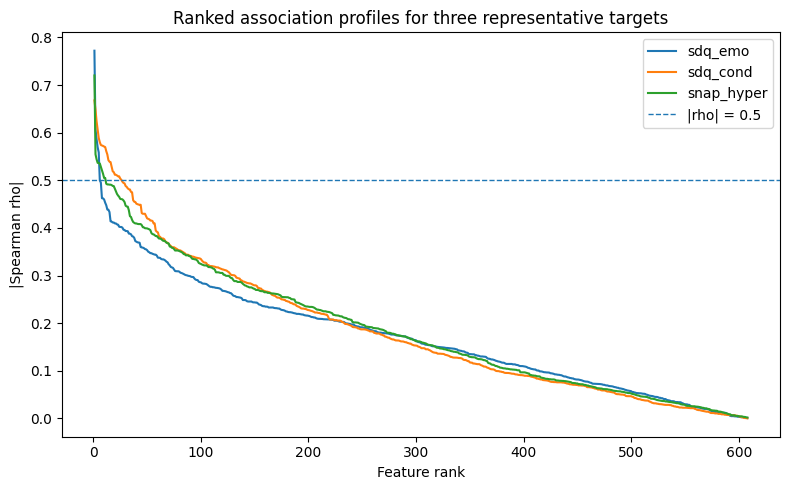

In [4]:

#####10 个 continuous targets 的总览表，先获得全局地图
reg = df[df["rho"].notna()].copy()
reg["abs_rho"] = reg["rho"].abs()

overview = (
    reg.groupby("target")
    .agg(
        n_features=("feature", "nunique"),
        n_abs_rho_ge_05=("abs_rho", lambda x: (x >= 0.5).sum()),
        max_abs_rho=("abs_rho", "max"),
        min_q_fdr=("q_fdr", "min"),
        n_loo_r2cv_gt_0=("loo_r2cv", lambda x: (x > 0).sum()),
        max_loo_r2cv=("loo_r2cv", "max"),
    )
    .reset_index()
)

print(overview.round(3).to_string(index=False))

import matplotlib.pyplot as plt

targets_to_compare = [
    "sdq_emo",
    "sdq_cond",
    "snap_hyper"
]

fig, ax = plt.subplots(figsize=(8, 5))

for target in targets_to_compare:
    values = (
        reg.loc[reg["target"] == target, "abs_rho"]
        .sort_values(ascending=False)
        .reset_index(drop=True)
    )

    ax.plot(
        range(1, len(values) + 1),
        values,
        label=target
    )

ax.axhline(
    0.5,
    linestyle="--",
    linewidth=1,
    label="|rho| = 0.5"
)

ax.set_xlabel("Feature rank")
ax.set_ylabel("|Spearman rho|")
ax.set_title("Ranked association profiles for three representative targets")
ax.legend()

plt.tight_layout()
plt.show()


In [5]:

sdq_cond_high = (
    reg[
        (reg["target"] == "sdq_cond")
        & (reg["abs_rho"] >= 0.5)
    ]
    .sort_values("abs_rho", ascending=False)
    [["feature", "rho"]]
)

print(sdq_cond_high.to_string(index=False))

               feature       rho
   stl_bout_cv_w10_p50  0.667688
    stl_bout_cv_w5_p60  0.648388
               uaY_max -0.624033
   stl_bout_cv_w10_p60  0.606571
            jerk_range -0.588650
    stl_bout_cv_w2_p70  0.579919
              jerk_max -0.573945
             uaY_range -0.573026
    stl_bout_cv_w2_p80  0.572107
   stl_bout_cv_w10_p70  0.570728
              jerk_min  0.569809
             uaX_bp_mf -0.561078
    stl_bout_cv_w2_p60  0.554186
   stl_bout_cv_w10_p80  0.542238
          gyX_centroid -0.539021
    stl_bout_cv_w1_p80  0.538102
             uaX_range -0.528912
               uaZ_max -0.518802
    stl_bout_cv_w5_p70  0.516964
stl_bout_median_w2_p80 -0.511655
    stl_bout_cv_w5_p50  0.511450
               gyX_min  0.510071
           uaMag_range -0.508233
             uaMag_max -0.508233
              uaY_kurt -0.503638
    stl_bout_cv_w1_p70  0.500881


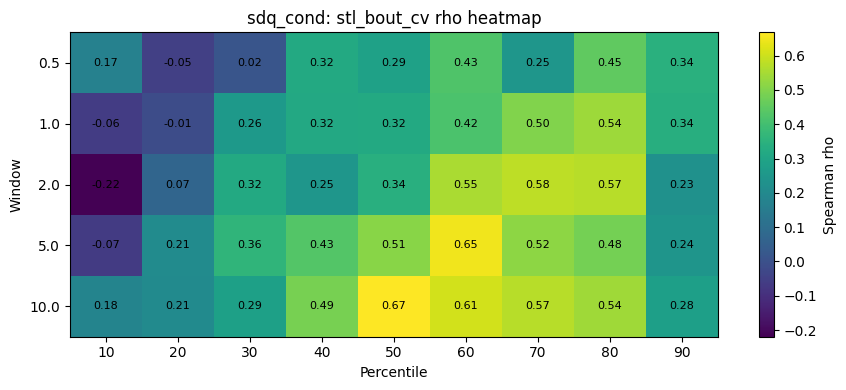

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# 先确保 reg 已经存在
# reg = df[df["rho"].notna()].copy()
# reg["abs_rho"] = reg["rho"].abs()

tmp = reg[
    (reg["target"] == "sdq_cond")
    & (reg["feature"].str.startswith("stl_bout_cv_"))
].copy()

# 提取 window 和 percentile
tmp[["window", "percentile"]] = tmp["feature"].str.extract(
    r"_w([0-9.]+)_p(\d+)$"
)

tmp["window"] = tmp["window"].astype(float)
tmp["percentile"] = tmp["percentile"].astype(int)

# 做成矩阵
rho_grid = (
    tmp.pivot(index="window", columns="percentile", values="rho")
    .sort_index()
    .sort_index(axis=1)
)

# 画热力图
fig, ax = plt.subplots(figsize=(9, 4))

im = ax.imshow(rho_grid.values, aspect="auto", origin="upper")

# 坐标轴标签
ax.set_xticks(range(len(rho_grid.columns)))
ax.set_xticklabels(rho_grid.columns)

ax.set_yticks(range(len(rho_grid.index)))
ax.set_yticklabels(rho_grid.index)

ax.set_xlabel("Percentile")
ax.set_ylabel("Window")
ax.set_title("sdq_cond: stl_bout_cv rho heatmap")

# 在每个格子里写数字
for i in range(rho_grid.shape[0]):
    for j in range(rho_grid.shape[1]):
        value = rho_grid.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8)

# 色条
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Spearman rho")

plt.tight_layout()
plt.show()

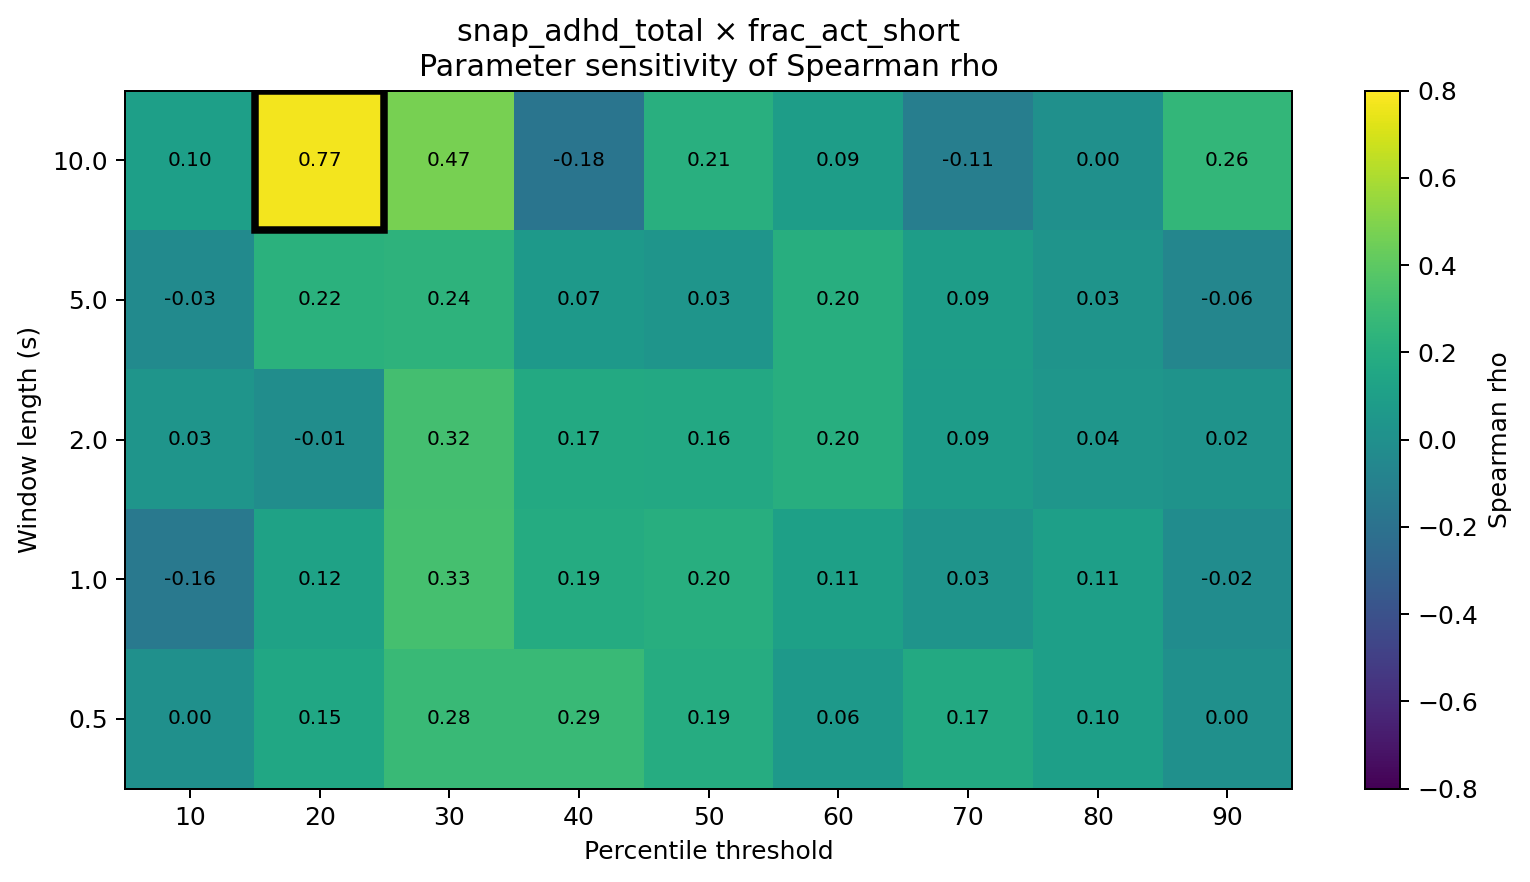

In [29]:
import numpy as np
import matplotlib.pyplot as plt

heat = (
    reg.loc[
        (reg["target"] == "snap_adhd_total")
        & reg["feature"].str.startswith("frac_act_short_"),
        ["feature", "rho"]
    ]
    .copy()
)

# 从 feature 名提取 window 和 percentile
heat["window"] = heat["feature"].str.extract(
    r"_w([0-9.]+)_p"
).astype(float)

heat["percentile"] = heat["feature"].str.extract(
    r"_p(\d+)$"
).astype(int)

grid = heat.pivot(
    index="window",
    columns="percentile",
    values="rho"
).sort_index()

fig, ax = plt.subplots(figsize=(9, 5), dpi=180)

im = ax.imshow(
    grid.values,
    aspect="auto",
    origin="lower",
    vmin=-0.8,
    vmax=0.8
)

ax.set_xticks(np.arange(len(grid.columns)))
ax.set_xticklabels(grid.columns)

ax.set_yticks(np.arange(len(grid.index)))
ax.set_yticklabels(grid.index)

ax.set_xlabel("Percentile threshold")
ax.set_ylabel("Window length (s)")
ax.set_title(
    "snap_adhd_total × frac_act_short\n"
    "Parameter sensitivity of Spearman rho"
)

# 每格写 rho
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        val = grid.iloc[i, j]
        ax.text(
            j, i,
            f"{val:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

# 给 w10, p20 画框
i_best = list(grid.index).index(10.0)
j_best = list(grid.columns).index(20)

rect = plt.Rectangle(
    (j_best - 0.5, i_best - 0.5),
    1, 1,
    fill=False,
    linewidth=3
)
ax.add_patch(rect)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Spearman rho")

plt.tight_layout()
plt.show()

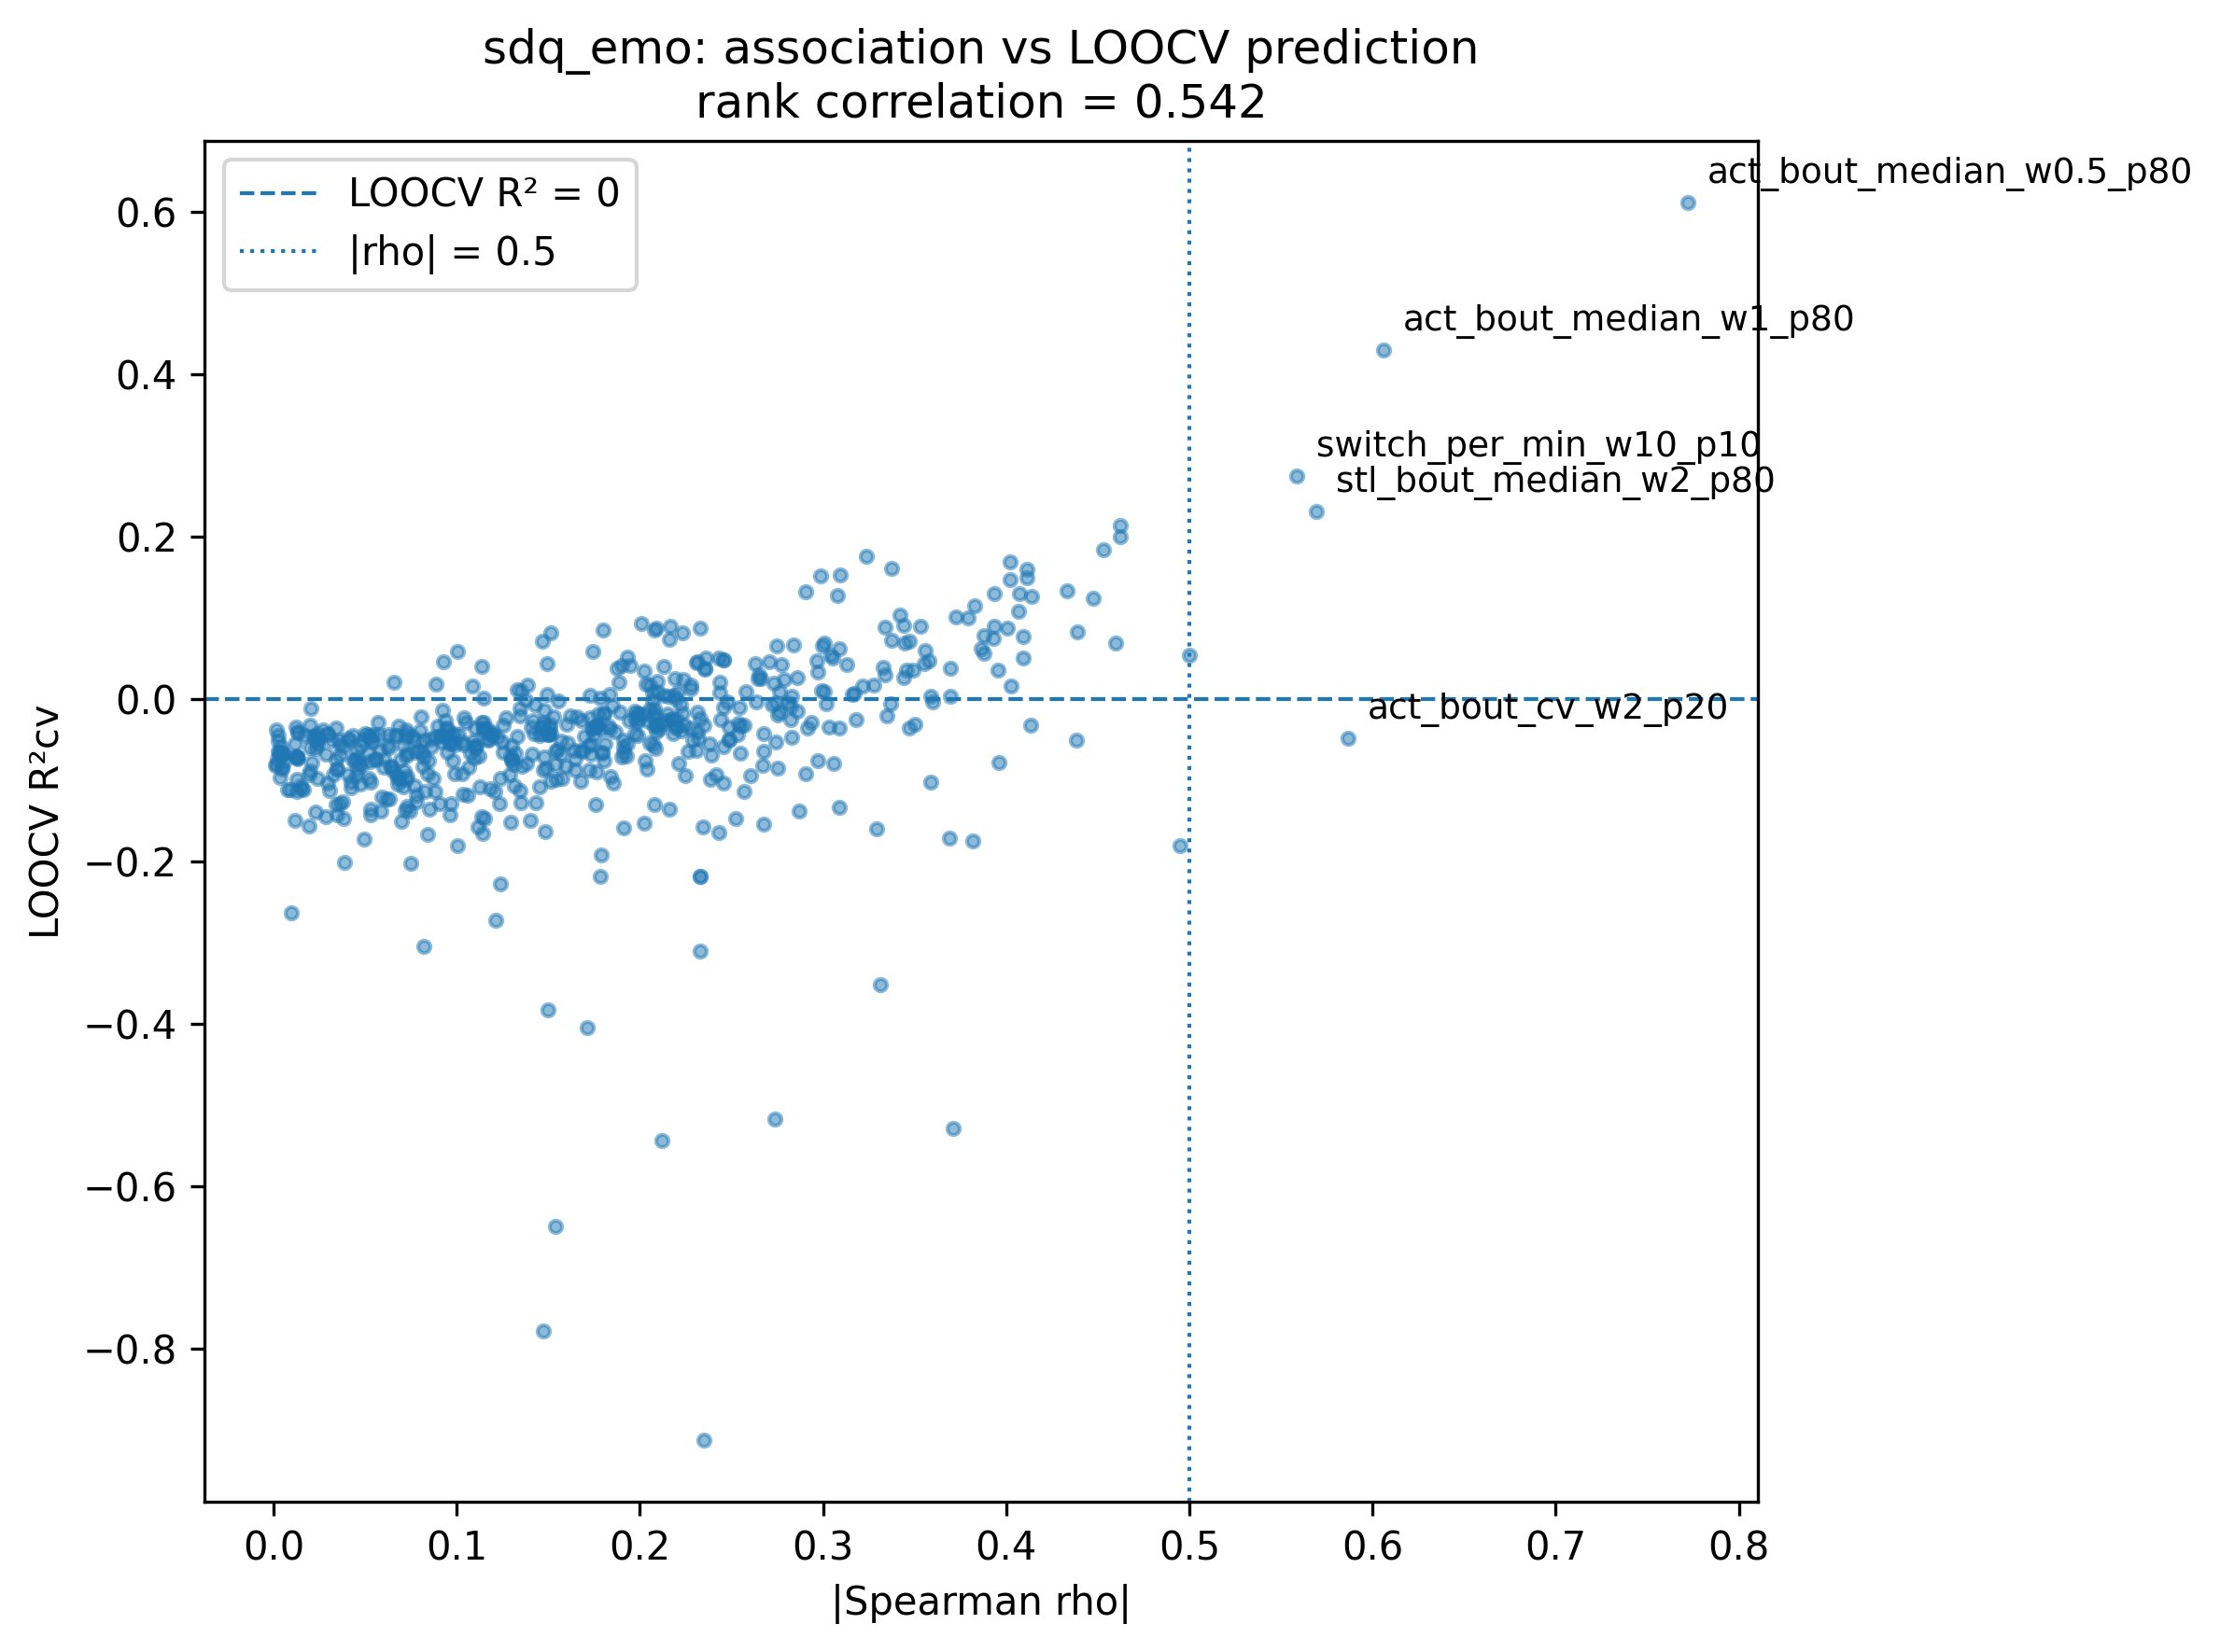

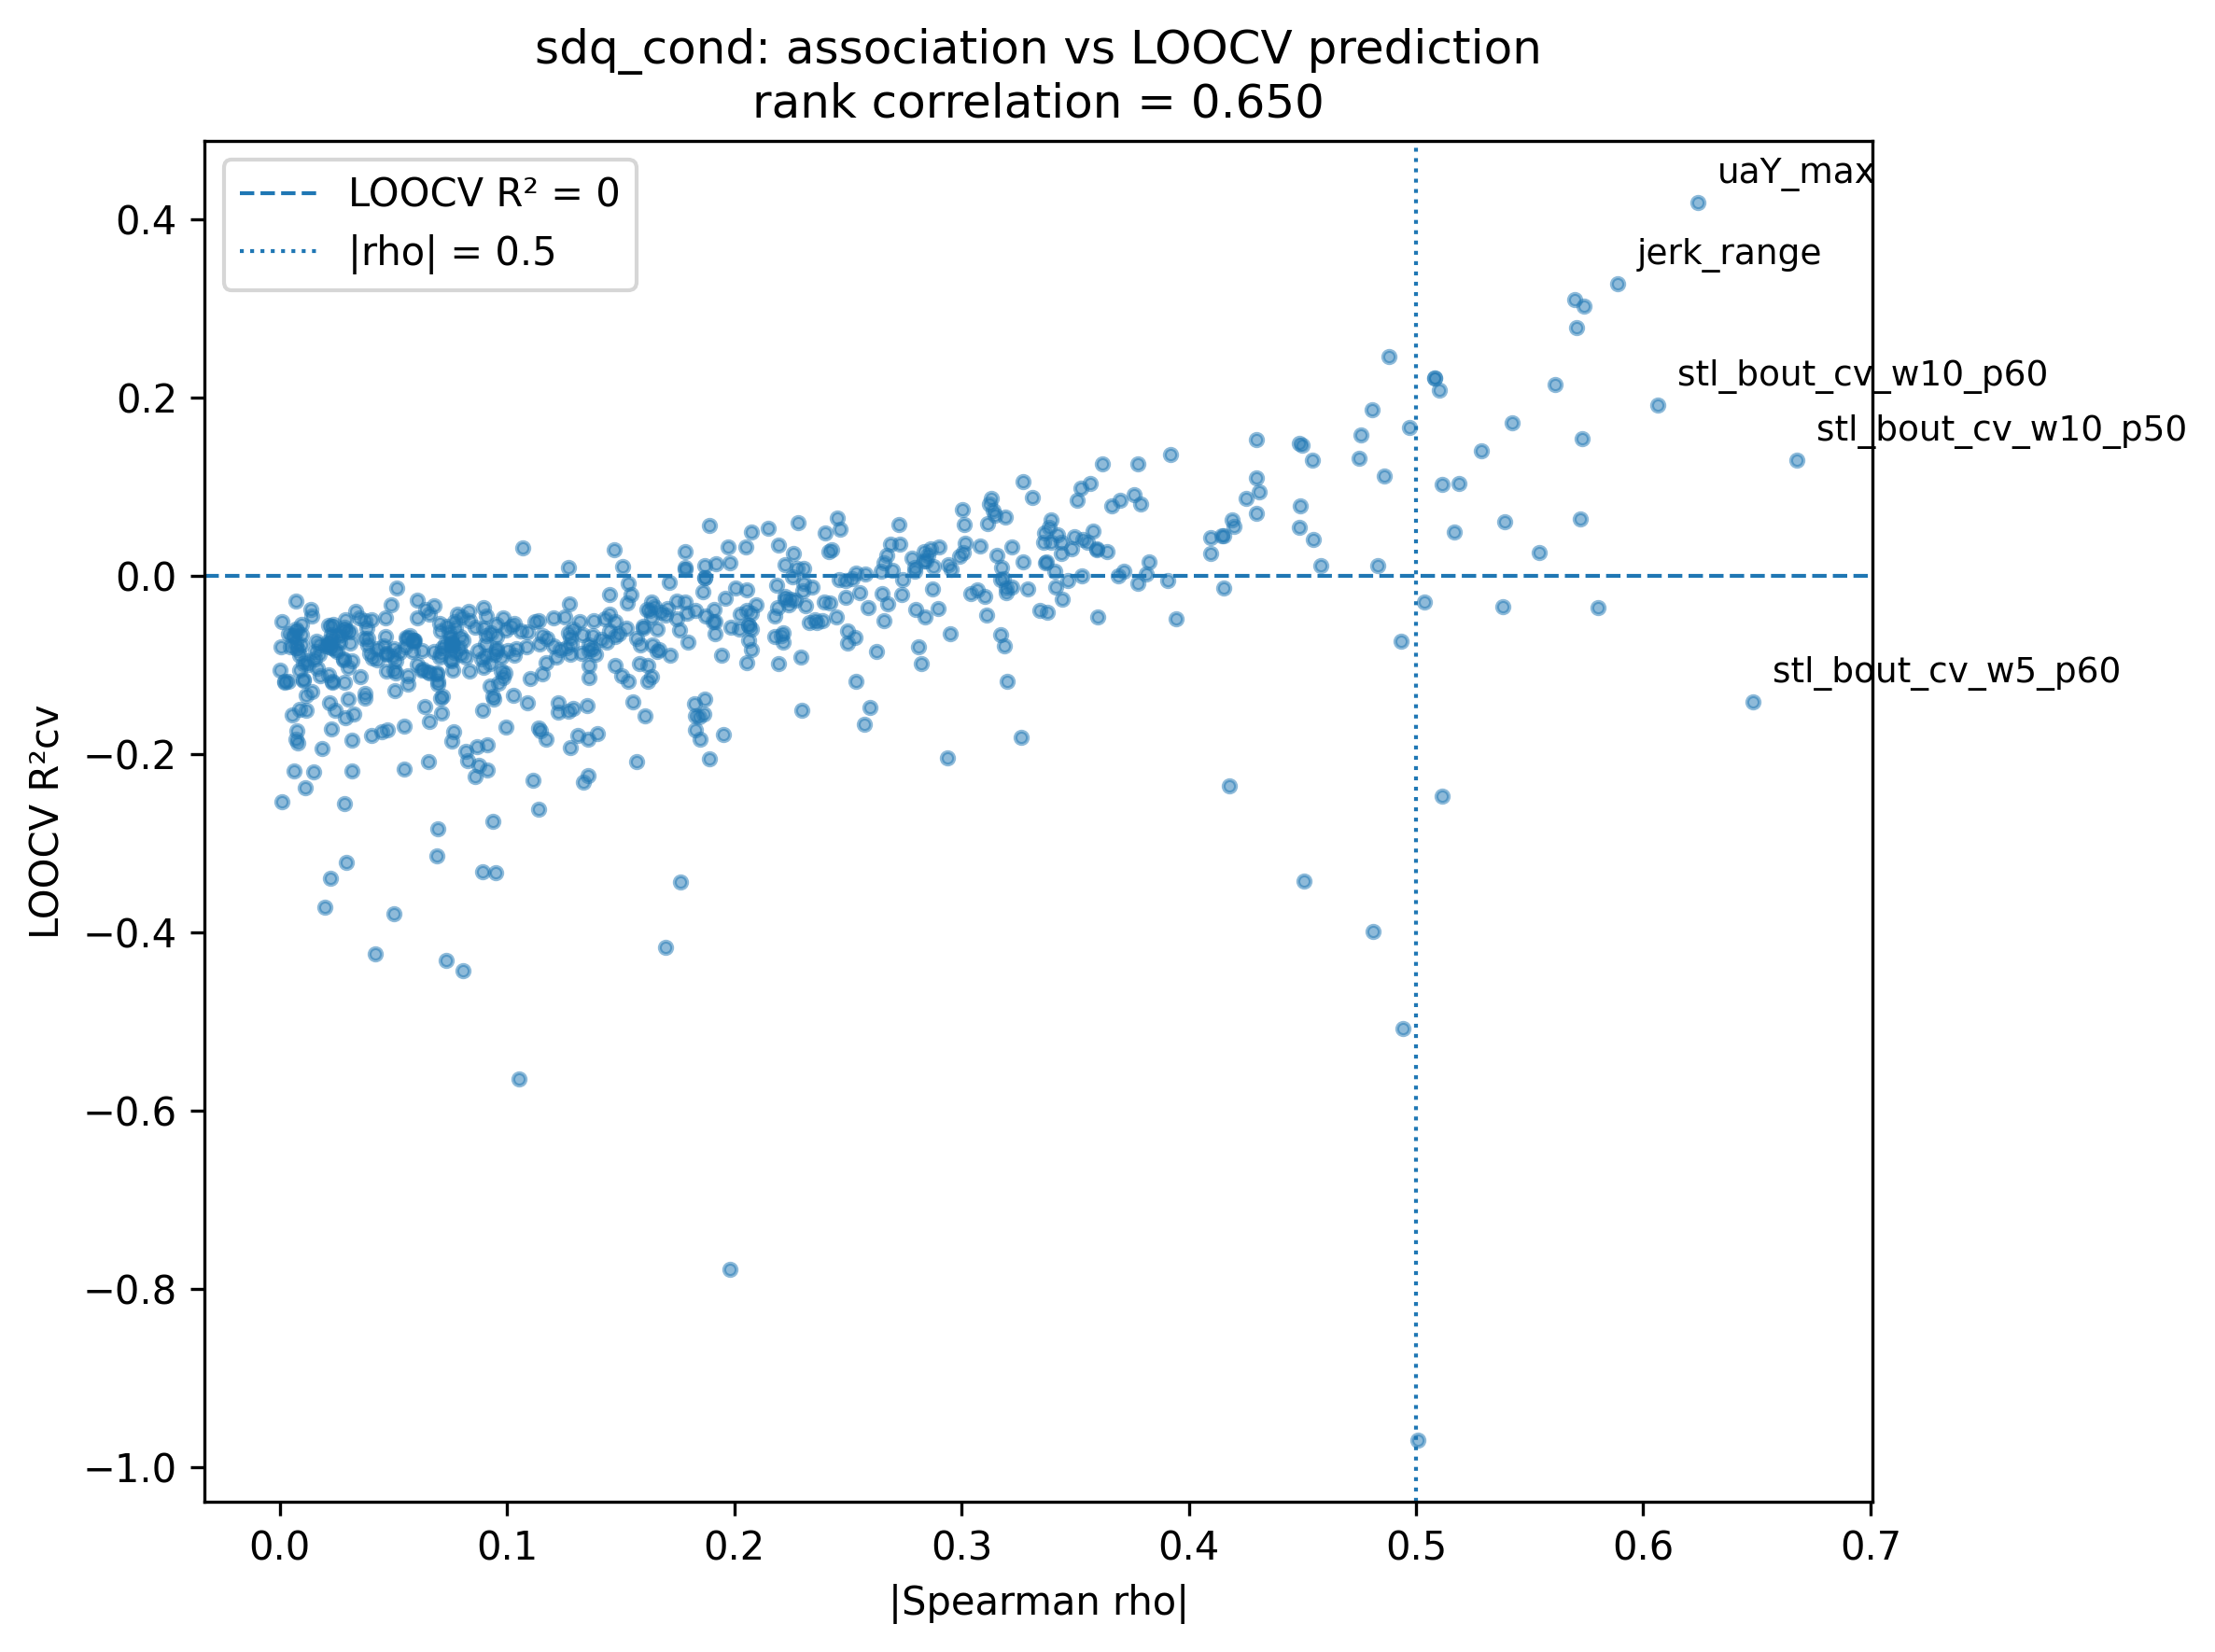

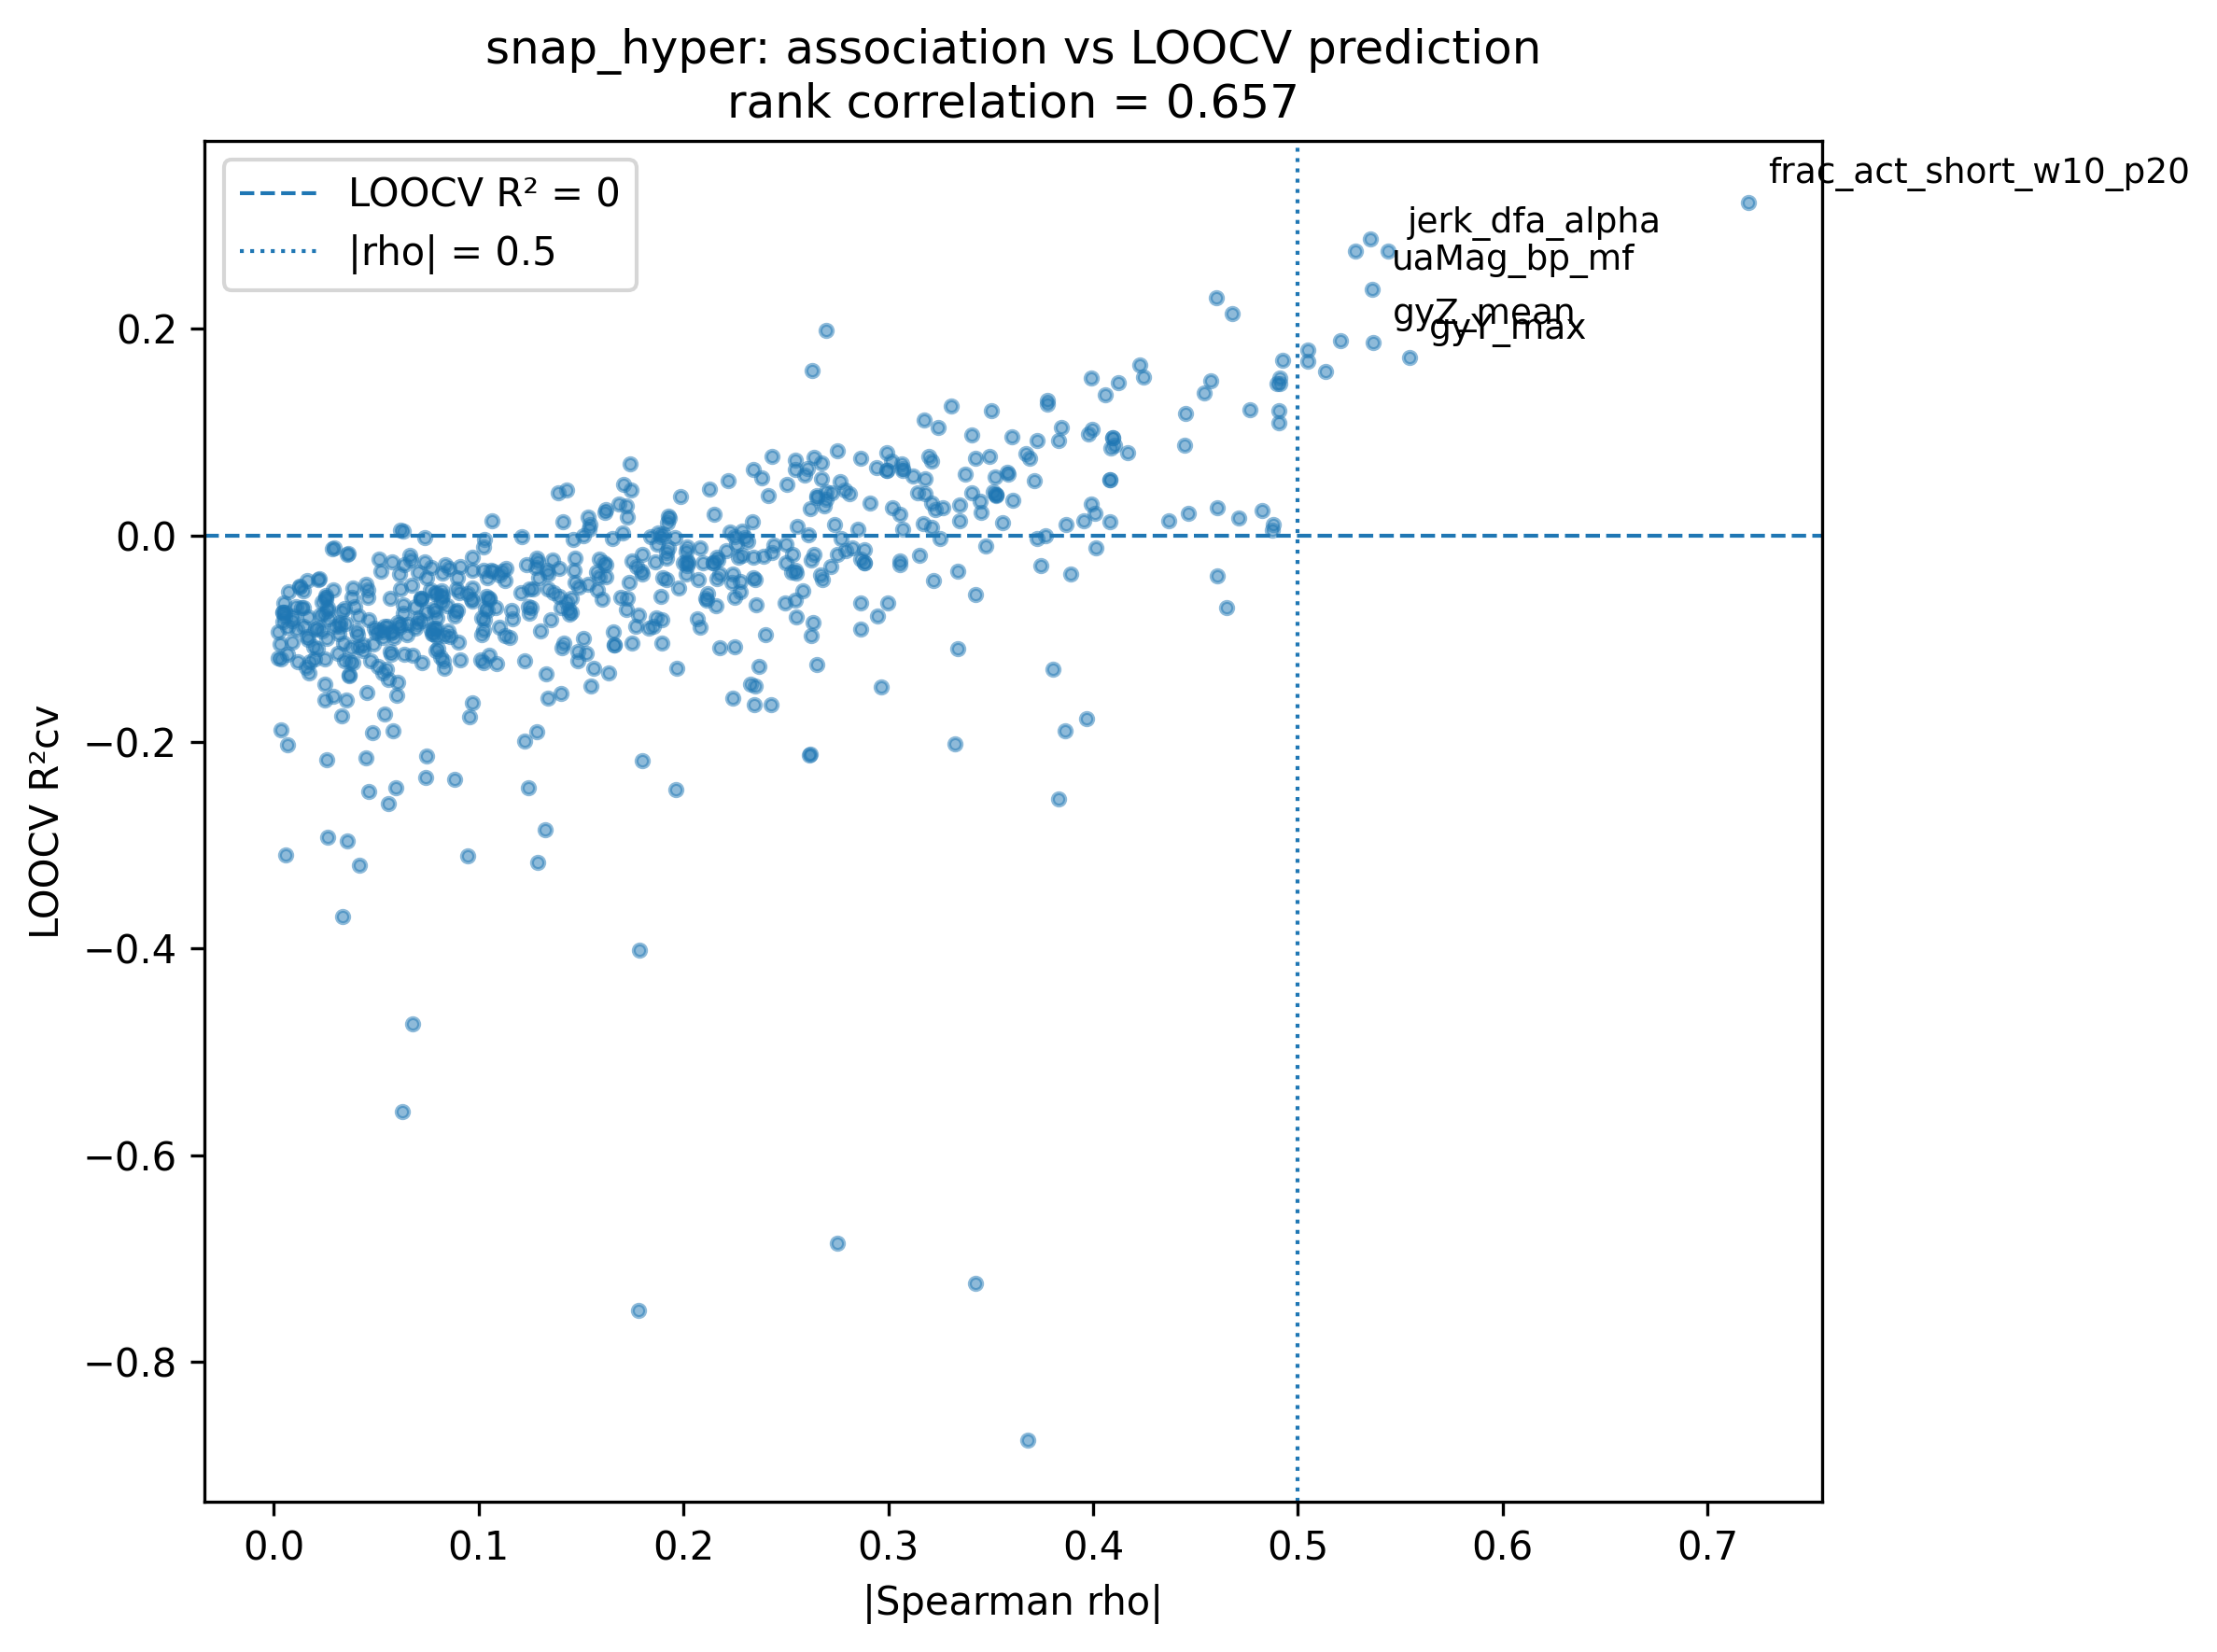

In [7]:
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

targets_to_check = [
    "sdq_emo",
    "sdq_cond",
    "snap_hyper"
]

for target in targets_to_check:
    plot_df = (
        reg.loc[
            reg["target"] == target,
            ["feature", "abs_rho", "loo_r2cv"]
        ]
        .dropna()
        .copy()
    )

    # 描述 |rho| 排名和 R²cv 排名是否一致
    rank_rho, rank_p = spearmanr(
        plot_df["abs_rho"],
        plot_df["loo_r2cv"]
    )

    fig, ax = plt.subplots(figsize=(8, 6)
                           ,dpi=300)

    ax.scatter(
        plot_df["abs_rho"],
        plot_df["loo_r2cv"],
        s=10,
        alpha=0.5
    )

    # R²cv = 0：是否超过留一均值 baseline
    ax.axhline(
        0,
        linestyle="--",
        linewidth=1,
        label="LOOCV R² = 0"
    )

    # 之前用于观察的 |rho| = 0.5
    ax.axvline(
        0.5,
        linestyle=":",
        linewidth=1,
        label="|rho| = 0.5"
    )

    # 标出 |rho| 最大的 5 个 feature
    top5 = plot_df.nlargest(5, "abs_rho")

    for _, row in top5.iterrows():
        ax.annotate(
            row["feature"],
            (row["abs_rho"], row["loo_r2cv"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9
        )

    ax.set_xlabel("|Spearman rho|")
    ax.set_ylabel("LOOCV R²cv")
    ax.set_title(
        f"{target}: association vs LOOCV prediction\n"
        f"rank correlation = {rank_rho:.3f}"
    )

    ax.legend()
    plt.tight_layout()
    plt.show()

In [8]:
targets_to_check = [
    "sdq_emo",
    "sdq_cond",
    "snap_hyper"
]

high_rho_table = (
    reg[
        reg["target"].isin(targets_to_check)
        & (reg["abs_rho"] >= 0.5)
    ]
    [
        [
            "target",
            "feature",
            "rho",
            "loo_r2cv",
            "loo_rmse",
            "loo_mae"
        ]
    ]
    .sort_values(
        ["target", "loo_r2cv"],
        ascending=[True, False]
    )
)

print(high_rho_table.round(3).to_string(index=False))

    target                  feature    rho  loo_r2cv  loo_rmse  loo_mae
  sdq_cond                  uaY_max -0.624     0.419     0.723    0.565
  sdq_cond               jerk_range -0.589     0.328     0.777    0.621
  sdq_cond                 jerk_min  0.570     0.310     0.788    0.624
  sdq_cond                 jerk_max -0.574     0.303     0.792    0.624
  sdq_cond      stl_bout_cv_w10_p70  0.571     0.279     0.806    0.665
  sdq_cond              uaMag_range -0.508     0.222     0.837    0.664
  sdq_cond                uaMag_max -0.508     0.222     0.837    0.664
  sdq_cond                uaX_bp_mf -0.561     0.215     0.841    0.695
  sdq_cond                  gyX_min  0.510     0.209     0.844    0.672
  sdq_cond      stl_bout_cv_w10_p60  0.607     0.192     0.853    0.715
  sdq_cond      stl_bout_cv_w10_p80  0.542     0.172     0.863    0.674
  sdq_cond                uaY_range -0.573     0.155     0.872    0.690
  sdq_cond                uaX_range -0.529     0.141     0.879  


sdq_emo: 45 features with partial rho


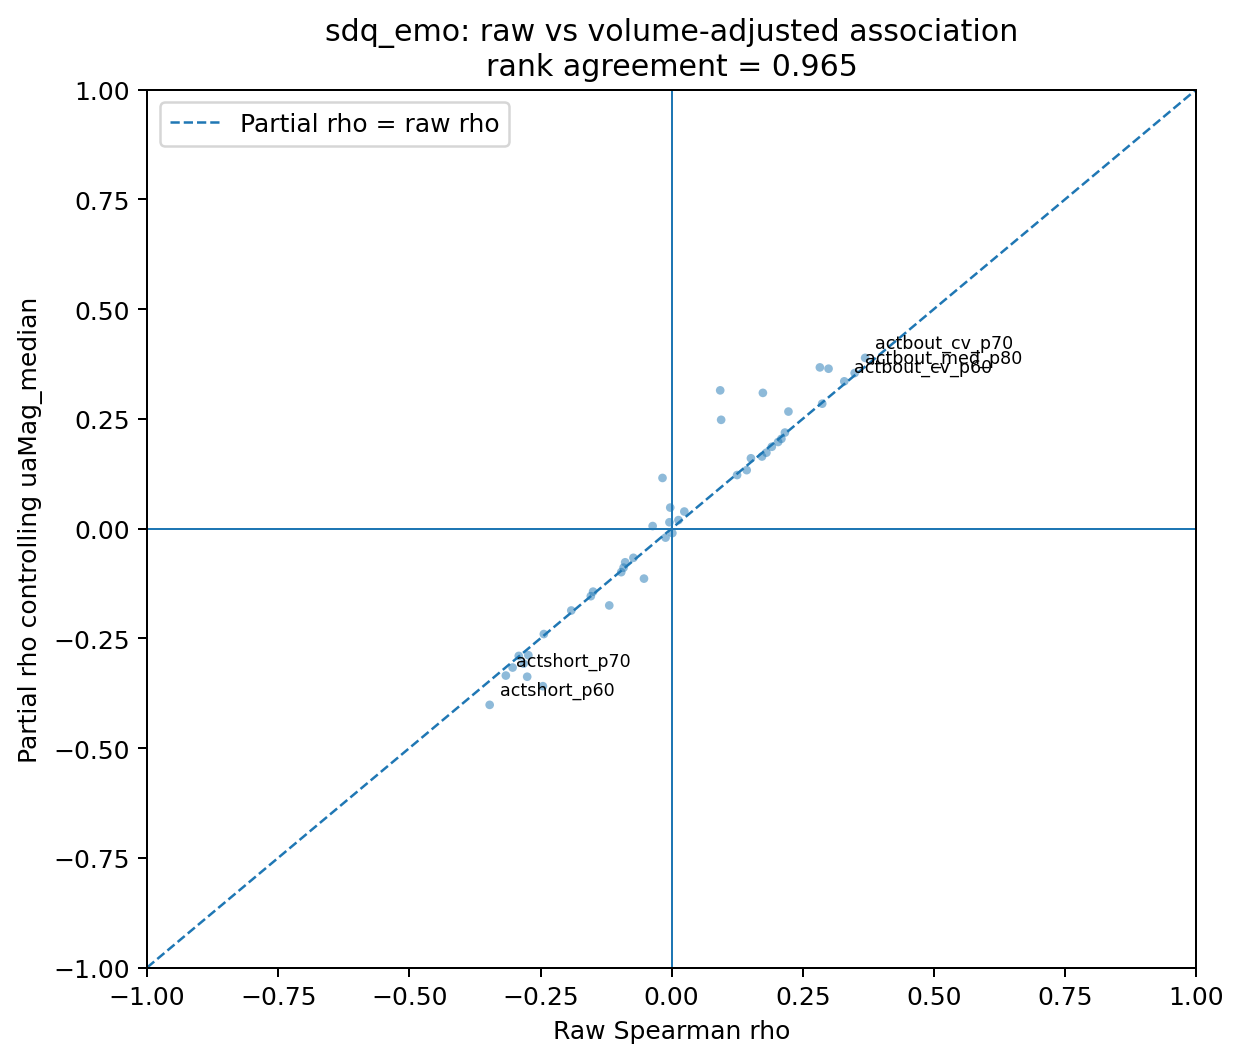


sdq_cond: 45 features with partial rho


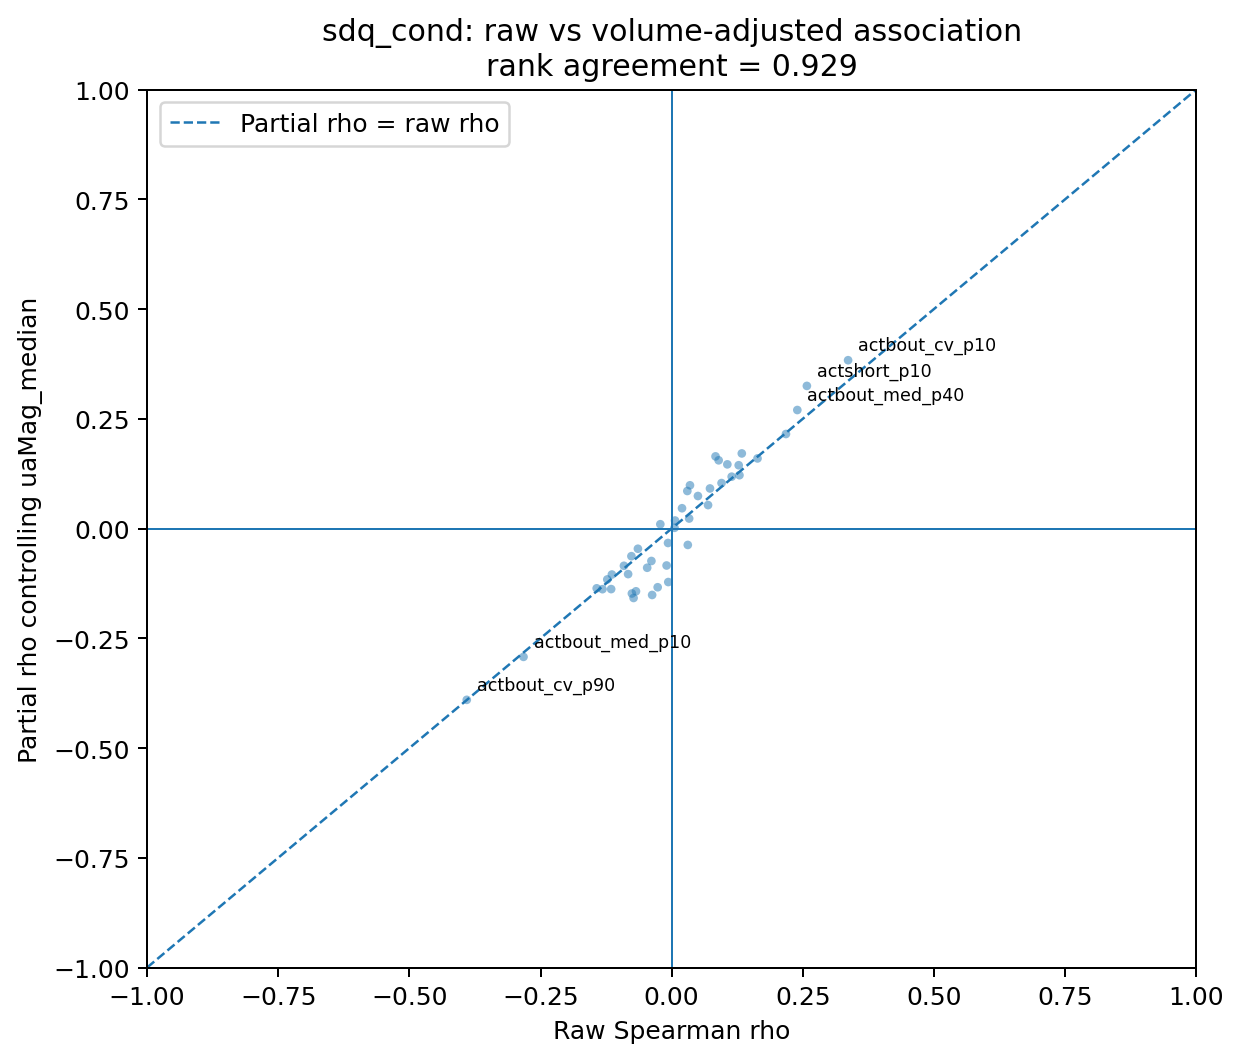


snap_hyper: 45 features with partial rho


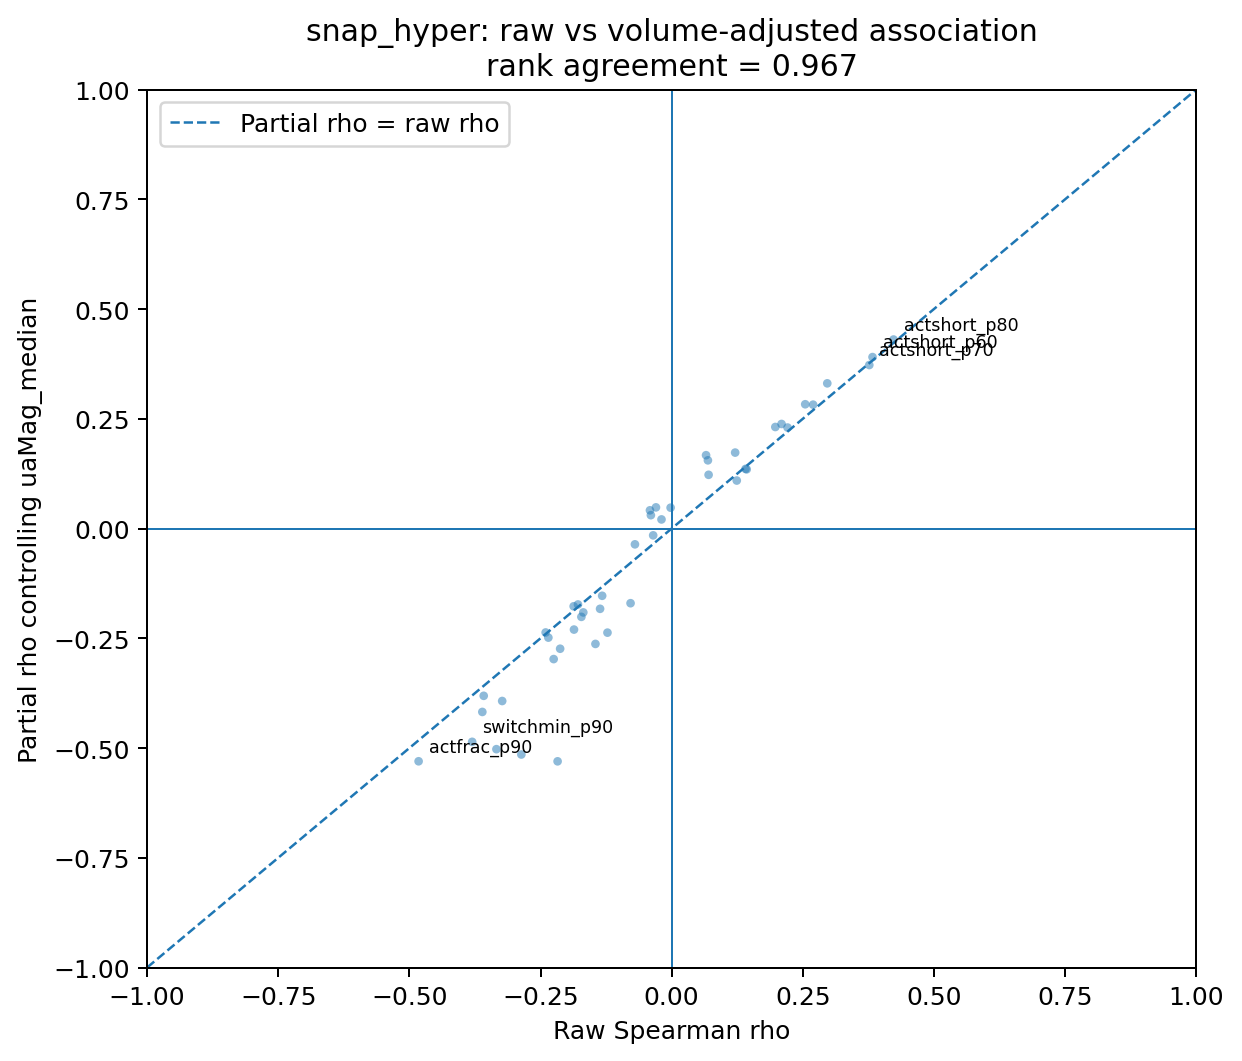

In [9]:
targets_to_check = [
    "sdq_emo",
    "sdq_cond",
    "snap_hyper"
]
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

for target in targets_to_check:
    partial_df = (
        reg.loc[
            (reg["target"] == target)
            & reg["rho_partial_uamag"].notna(),
            ["feature", "rho", "rho_partial_uamag"]
        ]
        .copy()
    )

    print(f"\n{target}: {len(partial_df)} features with partial rho")

    agreement, _ = spearmanr(
        partial_df["rho"],
        partial_df["rho_partial_uamag"]
    )

    fig, ax = plt.subplots(
        figsize=(7, 6),
        dpi=180
    )

    ax.scatter(
        partial_df["rho"],
        partial_df["rho_partial_uamag"],
        s=12,
        alpha=0.5,
        edgecolors="none"
    )

    # 原始 rho 与 partial rho 完全相同的位置
    ax.plot(
        [-1, 1],
        [-1, 1],
        linestyle="--",
        linewidth=1,
        label="Partial rho = raw rho"
    )

    ax.axhline(0, linewidth=0.8)
    ax.axvline(0, linewidth=0.8)

    # 标出原始 |rho| 最大的 5 个
    partial_df["abs_rho"] = partial_df["rho"].abs()
    top5 = partial_df.nlargest(5, "abs_rho")

    for _, row in top5.iterrows():
        ax.annotate(
            row["feature"],
            (
                row["rho"],
                row["rho_partial_uamag"]
            ),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=7
        )

    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)

    ax.set_xlabel("Raw Spearman rho")
    ax.set_ylabel("Partial rho controlling uaMag_median")
    ax.set_title(
        f"{target}: raw vs volume-adjusted association\n"
        f"rank agreement = {agreement:.3f}"
    )

    ax.legend()
    plt.tight_layout()
    plt.show()

In [10]:
summary_rows = []

for target in targets_to_check:
    tmp = reg.loc[
        (reg["target"] == target)
        & reg["rho_partial_uamag"].notna()
    ].copy()

    tmp["abs_raw"] = tmp["rho"].abs()
    tmp["abs_partial"] = tmp["rho_partial_uamag"].abs()

    summary_rows.append({
        "target": target,
        "n_features": len(tmp),

        "median_abs_raw_rho":
            tmp["abs_raw"].median(),

        "median_abs_partial_rho":
            tmp["abs_partial"].median(),

        # 正数表示控制后绝对相关减弱
        "median_attenuation":
            (tmp["abs_raw"] - tmp["abs_partial"]).median(),

        "n_weakened":
            (tmp["abs_partial"] < tmp["abs_raw"]).sum(),

        "n_unchanged":
            (tmp["abs_partial"] == tmp["abs_raw"]).sum(),

        "n_strengthened":
            (tmp["abs_partial"] > tmp["abs_raw"]).sum(),

        "n_sign_flips":
            (
                tmp["rho"] * tmp["rho_partial_uamag"] < 0
            ).sum()
    })

partial_summary = pd.DataFrame(summary_rows)

print(
    partial_summary
    .round(3)
    .to_string(index=False)
)

    target  n_features  median_abs_raw_rho  median_abs_partial_rho  median_attenuation  n_weakened  n_unchanged  n_strengthened  n_sign_flips
   sdq_emo          45               0.174                   0.187              -0.009          17            0              28             5
  sdq_cond          45               0.077                   0.118              -0.021          14            0              31             2
snap_hyper          45               0.186                   0.230              -0.029          10            0              35             5


In [11]:
top_partial_rows = []

for target in targets_to_check:
    tmp = reg.loc[
        (reg["target"] == target)
        & reg["rho_partial_uamag"].notna(),
        ["target", "feature", "rho", "rho_partial_uamag"]
    ].copy()

    tmp["abs_raw"] = tmp["rho"].abs()
    tmp["abs_partial"] = tmp["rho_partial_uamag"].abs()

    # 正数表示控制后增强，负数表示减弱
    tmp["change_in_abs_rho"] = (
        tmp["abs_partial"] - tmp["abs_raw"]
    )

    top5 = tmp.nlargest(5, "abs_raw")
    top_partial_rows.append(top5)

top_partial = pd.concat(top_partial_rows)

print(
    top_partial[
        [
            "target",
            "feature",
            "rho",
            "rho_partial_uamag",
            "change_in_abs_rho"
        ]
    ]
    .round(3)
    .to_string(index=False)
)

    target         feature    rho  rho_partial_uamag  change_in_abs_rho
   sdq_emo  actbout_cv_p70  0.369              0.389              0.020
   sdq_emo actbout_med_p80  0.349              0.354              0.005
   sdq_emo    actshort_p60 -0.347             -0.402              0.055
   sdq_emo  actbout_cv_p60  0.329              0.335              0.006
   sdq_emo    actshort_p70 -0.316             -0.335              0.019
  sdq_cond  actbout_cv_p90 -0.391             -0.390             -0.000
  sdq_cond  actbout_cv_p10  0.336              0.384              0.047
  sdq_cond actbout_med_p10 -0.282             -0.292              0.010
  sdq_cond    actshort_p10  0.258              0.325              0.067
  sdq_cond actbout_med_p40  0.240              0.270              0.030
snap_hyper     actfrac_p90 -0.482             -0.530              0.048
snap_hyper    actshort_p80  0.423              0.431              0.008
snap_hyper    actshort_p60  0.383              0.391            

In [12]:
##### 把 10 个 target 的关联、LOOCV 和 partial-rho 放到同一张总表里
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

rows = []

for target, tmp in reg.groupby("target"):
    tmp = tmp.copy()
    tmp["abs_rho"] = tmp["rho"].abs()

    # 1. Association 与 LOOCV 的整体一致性
    ap = tmp[["abs_rho", "loo_r2cv"]].dropna()

    if len(ap) >= 3:
        assoc_pred_corr = spearmanr(
            ap["abs_rho"],
            ap["loo_r2cv"]
        ).statistic
    else:
        assoc_pred_corr = np.nan

    # 2. 高相关 features 的预测表现
    high = tmp[tmp["abs_rho"] >= 0.5]

    n_high = len(high)
    n_high_r2_positive = (high["loo_r2cv"] > 0).sum()

    if n_high > 0:
        prop_high_r2_positive = n_high_r2_positive / n_high
        median_high_r2 = high["loo_r2cv"].median()
    else:
        prop_high_r2_positive = np.nan
        median_high_r2 = np.nan

    # 3. 只对有 partial rho 的 Path B features
    partial = tmp[tmp["rho_partial_uamag"].notna()].copy()

    partial["abs_raw"] = partial["rho"].abs()
    partial["abs_adjusted"] = partial["rho_partial_uamag"].abs()

    # 正数 = 控制 uaMag_median 后关联增强
    partial["change_abs"] = (
        partial["abs_adjusted"] - partial["abs_raw"]
    )

    n_sign_flips = (
        partial["rho"] * partial["rho_partial_uamag"] < 0
    ).sum()

    rows.append({
        "target": target,

        # Association / significance
        "max_abs_rho": tmp["abs_rho"].max(),
        "n_abs_rho_ge_05": n_high,
        "min_q_fdr": tmp["q_fdr"].min(),

        # LOOCV
        "max_loo_r2cv": tmp["loo_r2cv"].max(),
        "assoc_pred_rankcorr": assoc_pred_corr,
        "n_high_rho_r2_positive": n_high_r2_positive,
        "prop_high_rho_r2_positive": prop_high_r2_positive,
        "median_high_rho_r2": median_high_r2,

        # Partial rho
        "n_partial_features": len(partial),
        "median_abs_raw_partialset": partial["abs_raw"].median(),
        "median_abs_partial_rho": partial["abs_adjusted"].median(),
        "median_partial_change": partial["change_abs"].median(),
        "n_partial_strengthened": (
            partial["change_abs"] > 0
        ).sum(),
        "n_partial_weakened": (
            partial["change_abs"] < 0
        ).sum(),
        "n_partial_sign_flips": n_sign_flips
    })

all_target_summary = (
    pd.DataFrame(rows)
    .sort_values("max_abs_rho", ascending=False)
    .reset_index(drop=True)
)

print(
    all_target_summary
    .round(3)
    .to_string(index=False)
)

         target  max_abs_rho  n_abs_rho_ge_05  min_q_fdr  max_loo_r2cv  assoc_pred_rankcorr  n_high_rho_r2_positive  prop_high_rho_r2_positive  median_high_rho_r2  n_partial_features  median_abs_raw_partialset  median_abs_partial_rho  median_partial_change  n_partial_strengthened  n_partial_weakened  n_partial_sign_flips
        sdq_emo        0.772                5      0.006         0.611                0.542                       4                      0.800               0.274                  45                      0.174                   0.187                  0.009                      28                  17                     5
snap_adhd_total        0.772               12      0.006         0.381                0.576                      12                      1.000               0.174                  45                      0.188                   0.212                  0.025                      34                  11                     3
     snap_inatt        0.767   

In [13]:
##### 时间结构 features 与其他 signal features，究竟哪一类在驱动这些结果？
import numpy as np
import pandas as pd

family_reg = reg.copy()

# Path B：有 partial-rho 的那 45 个 feature
is_path_b = family_reg["rho_partial_uamag"].notna()

# Path A：带有明确 window + percentile 参数的特征
is_path_a = family_reg["feature"].str.contains(
    r"_w(?:0\.5|1|2|5|10)_p(?:10|20|30|40|50|60|70|80|90)$",
    regex=True,
    na=False
) & ~is_path_b

family_reg["broad_family"] = np.select(
    [is_path_b, is_path_a],
    ["Path B", "Path A"],
    default="Other"
)

print(
    family_reg[
        ["feature", "broad_family"]
    ]
    .drop_duplicates()
    ["broad_family"]
    .value_counts()
)

broad_family
Other     293
Path A    270
Path B     45
Name: count, dtype: int64


In [14]:
feature_map = (
    family_reg[
        ["feature", "broad_family"]
    ]
    .drop_duplicates()
)

suspected_path_a = feature_map.loc[
    (feature_map["broad_family"] == "Other")
    & feature_map["feature"].str.contains(
        r"(_w|_p|bout|switch|actshort|frac_act)",
        case=False,
        regex=True,
        na=False
    ),
    "feature"
]

print(
    suspected_path_a
    .sort_values()
    .to_string(index=False)
)

    gyMag_acf_dom_peak
gyMag_acf_dom_period_s
     gyMag_peak_amp_cv
    gyMag_peak_amp_med
     gyMag_peak_ipi_cv
  gyMag_peak_ipi_med_s
   gyMag_peak_rate_min
       gyMag_permen_m3
     jerk_acf_dom_peak
 jerk_acf_dom_period_s
      jerk_peak_amp_cv
     jerk_peak_amp_med
      jerk_peak_ipi_cv
   jerk_peak_ipi_med_s
    jerk_peak_rate_min
        jerk_permen_m3
    uaMag_acf_dom_peak
uaMag_acf_dom_period_s
     uaMag_peak_amp_cv
    uaMag_peak_amp_med
     uaMag_peak_ipi_cv
  uaMag_peak_ipi_med_s
   uaMag_peak_rate_min
       uaMag_permen_m3
    within_win_sd_w0.5
      within_win_sd_w1
     within_win_sd_w10
      within_win_sd_w2
      within_win_sd_w5


/var/folders/8g/sgpc0wmd7q3frkcq7ybb5fv00000gn/T/ipykernel_5635/1743306559.py:10: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  & feature_map["feature"].str.contains(


In [15]:
suspected_window_features = feature_map.loc[
    (feature_map["broad_family"] == "Other")
    & feature_map["feature"].str.contains(
        r"_w",
        regex=True,
        na=False
    ),
    "feature"
]

print(
    suspected_window_features
    .sort_values()
    .to_string(index=False)
)

within_win_sd_w0.5
  within_win_sd_w1
 within_win_sd_w10
  within_win_sd_w2
  within_win_sd_w5


In [16]:
##### path A / path B / other 的 broad family 分类 不对呢， 需要把 within_win_sd 也归为 path A
is_path_b = family_reg["rho_partial_uamag"].notna()

is_path_a_grid = family_reg["feature"].str.contains(
    r"_w(?:0\.5|1|2|5|10)_p(?:10|20|30|40|50|60|70|80|90)$",
    regex=True,
    na=False
)

is_within_win_sd = family_reg["feature"].str.fullmatch(
    r"within_win_sd_w(?:0\.5|1|2|5|10)",
    na=False
)

is_path_a = (
    is_path_a_grid
    | is_within_win_sd
) & ~is_path_b

family_reg["broad_family"] = np.select(
    [is_path_b, is_path_a],
    ["Path B", "Path A"],
    default="Other"
)

print(
    family_reg[
        ["feature", "broad_family"]
    ]
    .drop_duplicates()
    ["broad_family"]
    .value_counts()
)

broad_family
Other     288
Path A    275
Path B     45
Name: count, dtype: int64


In [17]:
##### 重新来，10 个 target 的 broad family 总览表。“目前的主要信号究竟来自 Path A、Path B，还是传统/非线性 features”
import numpy as np
import pandas as pd

family_compare = family_reg.copy()
family_compare["abs_rho"] = family_compare["rho"].abs()

family_summary = (
    family_compare
    .groupby(["target", "broad_family"])
    .agg(
        n_features=("feature", "size"),

        # 整个 family 的典型关联强度
        median_abs_rho=("abs_rho", "median"),

        # family 中较强的上层 10%
        p90_abs_rho=("abs_rho", lambda x: x.quantile(0.90)),

        max_abs_rho=("abs_rho", "max"),

        # 强关联比例，解决 family 大小不相等的问题
        prop_abs_rho_ge_05=(
            "abs_rho",
            lambda x: (x >= 0.5).mean()
        ),

        # FDR
        n_q_fdr_lt_05=(
            "q_fdr",
            lambda x: (x < 0.05).sum()
        ),
        min_q_fdr=("q_fdr", "min"),

        # LOOCV
        prop_loo_r2_positive=(
            "loo_r2cv",
            lambda x: (x > 0).mean()
        ),
        median_loo_r2cv=("loo_r2cv", "median"),
        max_loo_r2cv=("loo_r2cv", "max")
    )
    .reset_index()
)

print(
    family_summary[
        [
            "target",
            "broad_family",
            "n_features",
            "median_abs_rho",
            "p90_abs_rho",
            "prop_abs_rho_ge_05",
            "n_q_fdr_lt_05",
            "min_q_fdr",
            "prop_loo_r2_positive",
            "median_loo_r2cv",
            "max_loo_r2cv"
        ]
    ]
    .round(3)
    .to_string(index=False)
)

         target broad_family  n_features  median_abs_rho  p90_abs_rho  prop_abs_rho_ge_05  n_q_fdr_lt_05  min_q_fdr  prop_loo_r2_positive  median_loo_r2cv  max_loo_r2cv
       sdq_cond        Other         288           0.160        0.390               0.045              0      0.231                 0.243           -0.061         0.419
       sdq_cond       Path A         275           0.162        0.403               0.047              0      0.231                 0.262           -0.064         0.279
       sdq_cond       Path B          45           0.077        0.231               0.000              0      0.599                 0.044           -0.065         0.048
        sdq_emo        Other         288           0.165        0.309               0.000              0      0.880                 0.188           -0.046         0.133
        sdq_emo       Path A         275           0.152        0.355               0.018              1      0.006                 0.295           -0.044 

In [18]:
##### 拆开other
import re
import numpy as np

nonlinear_metrics = [
    "dfa_alpha",
    "hurst_rs",
    "permen_m3",
    "lz_c",
    "acf_tau_1e_s",
    "acf_dom_period_s",
    "acf_dom_peak",
    "peak_rate_min",
    "peak_ipi_med_s",
    "peak_ipi_cv",
    "peak_amp_med",
    "peak_amp_cv"
]

nonlinear_pattern = (
    r"^(?:uaMag|gyMag|jerk)_(?:"
    + "|".join(map(re.escape, nonlinear_metrics))
    + r")$"
)

is_nonlinear = (
    family_reg["broad_family"].eq("Other")
    & family_reg["feature"].str.match(
        nonlinear_pattern,
        na=False
    )
)

family_reg["fine_family"] = np.select(
    [
        family_reg["broad_family"].eq("Path A"),
        family_reg["broad_family"].eq("Path B"),
        is_nonlinear
    ],
    [
        "Path A",
        "Path B",
        "Nonlinear"
    ],
    default="Conventional + duration"
)

fine_counts = (
    family_reg[
        ["feature", "fine_family"]
    ]
    .drop_duplicates()
    ["fine_family"]
    .value_counts()
)

print(fine_counts)

fine_compare = family_reg.copy()
fine_compare["abs_rho"] = fine_compare["rho"].abs()

fine_summary = (
    fine_compare
    .groupby(["target", "fine_family"])
    .agg(
        n_features=("feature", "size"),

        median_abs_rho=("abs_rho", "median"),

        p90_abs_rho=(
            "abs_rho",
            lambda x: x.quantile(0.90)
        ),

        max_abs_rho=("abs_rho", "max"),

        prop_abs_rho_ge_05=(
            "abs_rho",
            lambda x: (x >= 0.5).mean()
        ),

        n_q_fdr_lt_05=(
            "q_fdr",
            lambda x: (x < 0.05).sum()
        ),

        min_q_fdr=("q_fdr", "min"),

        prop_loo_r2_positive=(
            "loo_r2cv",
            lambda x: (x > 0).mean()
        ),

        median_loo_r2cv=("loo_r2cv", "median"),

        max_loo_r2cv=("loo_r2cv", "max")
    )
    .reset_index()
)

print(
    fine_summary[
        [
            "target",
            "fine_family",
            "n_features",
            "median_abs_rho",
            "p90_abs_rho",
            "prop_abs_rho_ge_05",
            "n_q_fdr_lt_05",
            "min_q_fdr",
            "prop_loo_r2_positive",
            "median_loo_r2cv",
            "max_loo_r2cv"
        ]
    ]
    .round(3)
    .to_string(index=False)
)

fine_family
Path A                     275
Conventional + duration    252
Path B                      45
Nonlinear                   36
Name: count, dtype: int64
         target             fine_family  n_features  median_abs_rho  p90_abs_rho  prop_abs_rho_ge_05  n_q_fdr_lt_05  min_q_fdr  prop_loo_r2_positive  median_loo_r2cv  max_loo_r2cv
       sdq_cond Conventional + duration         252           0.162        0.420               0.052              0      0.231                 0.258           -0.060         0.419
       sdq_cond               Nonlinear          36           0.149        0.306               0.000              0      0.664                 0.139           -0.084         0.034
       sdq_cond                  Path A         275           0.162        0.403               0.047              0      0.231                 0.262           -0.064         0.279
       sdq_cond                  Path B          45           0.077        0.231               0.000              0   

In [19]:
multiplicity_summary = (
    reg.groupby("target")
    .agg(
        n_features=("feature", "size"),

        n_perm_p_lt_05=(
            "perm_p",
            lambda x: (x < 0.05).sum()
        ),

        n_perm_p_lt_01=(
            "perm_p",
            lambda x: (x < 0.01).sum()
        ),

        n_perm_p_lt_001=(
            "perm_p",
            lambda x: (x < 0.001).sum()
        ),

        min_perm_p=("perm_p", "min"),

        n_q_fdr_lt_10=(
            "q_fdr",
            lambda x: (x < 0.10).sum()
        ),

        n_q_fdr_lt_05=(
            "q_fdr",
            lambda x: (x < 0.05).sum()
        ),

        min_q_fdr=("q_fdr", "min")
    )
    .reset_index()
    .sort_values("min_perm_p")
)

multiplicity_summary["prop_perm_p_lt_05"] = (
    multiplicity_summary["n_perm_p_lt_05"]
    / multiplicity_summary["n_features"]
)

print(
    multiplicity_summary[
        [
            "target",
            "n_perm_p_lt_05",
            "prop_perm_p_lt_05",
            "n_perm_p_lt_01",
            "n_perm_p_lt_001",
            "min_perm_p",
            "n_q_fdr_lt_10",
            "n_q_fdr_lt_05",
            "min_q_fdr"
        ]
    ]
    .round(4)
    .to_string(index=False)
)

         target  n_perm_p_lt_05  prop_perm_p_lt_05  n_perm_p_lt_01  n_perm_p_lt_001  min_perm_p  n_q_fdr_lt_10  n_q_fdr_lt_05  min_q_fdr
        sdq_emo              21             0.0345               5                1      0.0000              1              1     0.0061
snap_adhd_total              44             0.0724               8                1      0.0000              1              1     0.0061
     snap_inatt              25             0.0411               2                1      0.0000              1              1     0.0061
     snap_hyper              45             0.0740               7                1      0.0001              1              0     0.0608
       sdq_cond              57             0.0938              17                2      0.0006              0              0     0.2310
       sdq_peer              17             0.0280               6                0      0.0014              0              0     0.8330
      sdq_hyper              17          

In [20]:
surviving_rows = (
    family_reg.loc[
        family_reg["q_fdr"] < 0.10,
        [
            "target",
            "feature",
            "fine_family",
            "rho",
            "perm_p",
            "q_fdr",
            "loo_r2cv",
            "loo_rmse",
            "loo_mae",
            "rho_partial_uamag"
        ]
    ]
    .sort_values(["q_fdr", "target"])
)

print(
    surviving_rows
    .round(4)
    .to_string(index=False)
)

         target                  feature fine_family    rho  perm_p  q_fdr  loo_r2cv  loo_rmse  loo_mae  rho_partial_uamag
        sdq_emo act_bout_median_w0.5_p80      Path A 0.7720  0.0000 0.0061    0.6115    1.1105   0.7985                NaN
snap_adhd_total   frac_act_short_w10_p20      Path A 0.7718  0.0000 0.0061    0.3811    6.9415   5.3870                NaN
     snap_inatt   frac_act_short_w10_p20      Path A 0.7666  0.0000 0.0061    0.3760    3.7015   2.8429                NaN
     snap_hyper   frac_act_short_w10_p20      Path A 0.7200  0.0001 0.0608    0.3225    3.6434   2.8181                NaN


In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# 先放四个预设 ADHD outcomes，再放其他六个 outcomes
target_order = [
    "snap_adhd_total",
    "snap_inatt",
    "snap_hyper",
    "sdq_hyper",
    "sdq_emo",
    "sdq_cond",
    "sdq_peer",
    "sdq_pro",
    "sdq_totdiff",
    "snap_odd"
]

# 显示名称
target_labels = {
    "snap_adhd_total": "SNAP ADHD total",
    "snap_inatt": "SNAP inattention",
    "snap_hyper": "SNAP hyperactivity",
    "sdq_hyper": "SDQ hyperactivity",
    "sdq_emo": "SDQ emotional",
    "sdq_cond": "SDQ conduct",
    "sdq_peer": "SDQ peer",
    "sdq_pro": "SDQ prosocial",
    "sdq_totdiff": "SDQ total difficulties",
    "snap_odd": "SNAP ODD"
}

# 计算绝对 rho
table_df = reg.copy()
table_df["abs_rho"] = table_df["rho"].abs()

# 每个 target 汇总
table_df = (
    table_df
    .groupby("target")
    .agg(
        max_abs_rho=("abs_rho", "max"),
        min_q_fdr=("q_fdr", "min"),
        max_loo_r2cv=("loo_r2cv", "max")
    )
    .reindex(target_order)
    .reset_index()
)

# 替换为更易读的标签
table_df["Outcome"] = table_df["target"].map(target_labels)

# 最终列
table_df = table_df[
    [
        "Outcome",
        "max_abs_rho",
        "min_q_fdr",
        "max_loo_r2cv"
    ]
].rename(
    columns={
        "max_abs_rho": "Max |ρ|",
        "min_q_fdr": "Min FDR q",
        "max_loo_r2cv": "Max LOOCV R²"
    }
)

print(
    table_df
    .round(3)
    .to_string(index=False)
)

               Outcome  Max |ρ|  Min FDR q  Max LOOCV R²
       SNAP ADHD total    0.772      0.006         0.381
      SNAP inattention    0.767      0.006         0.376
    SNAP hyperactivity    0.720      0.061         0.322
     SDQ hyperactivity    0.590      0.922         0.260
         SDQ emotional    0.772      0.006         0.611
           SDQ conduct    0.668      0.231         0.419
              SDQ peer    0.618      0.833         0.237
         SDQ prosocial    0.572      0.916         0.233
SDQ total difficulties    0.528      0.975         0.190
              SNAP ODD    0.538      0.994         0.193


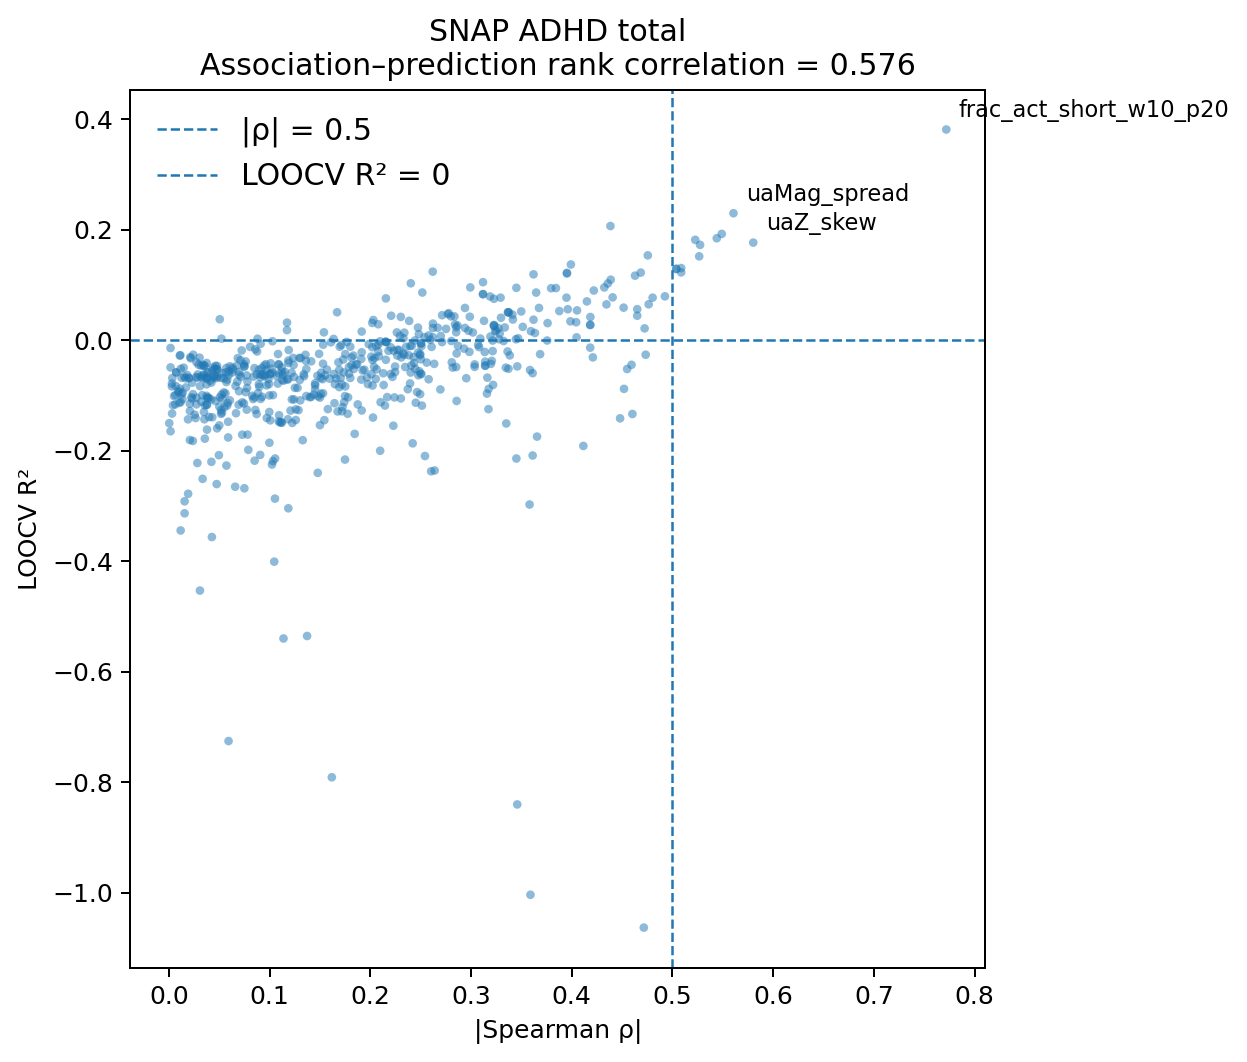

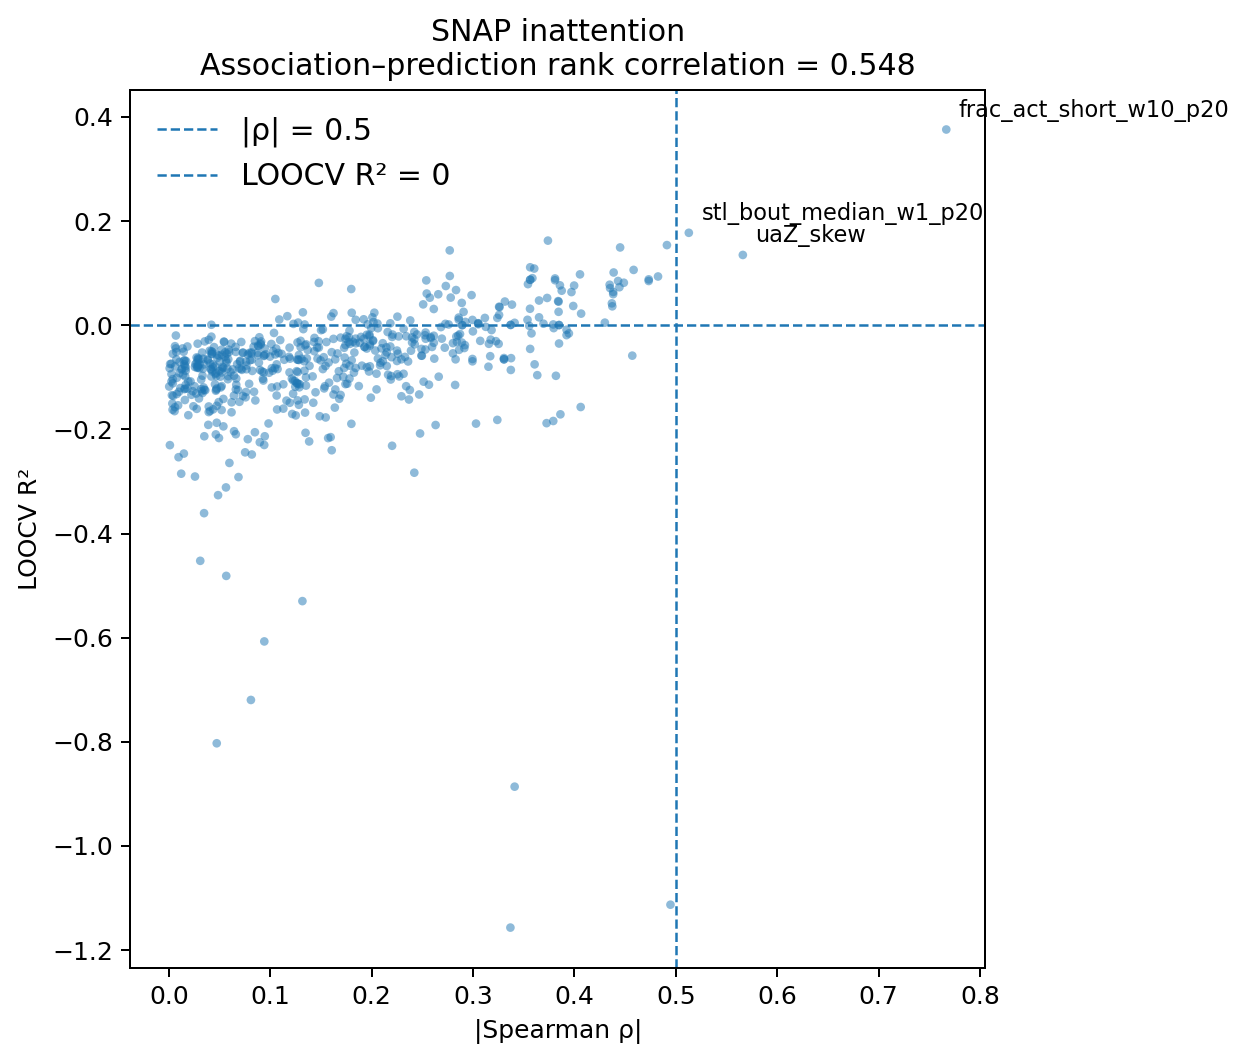

In [22]:
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

targets_to_plot = [
    "snap_adhd_total",
    "snap_inatt"
]

target_titles = {
    "snap_adhd_total": "SNAP ADHD total",
    "snap_inatt": "SNAP inattention"
}

for target in targets_to_plot:

    plot_df = (
        reg.loc[
            reg["target"] == target,
            ["feature", "rho", "loo_r2cv"]
        ]
        .dropna()
        .copy()
    )

    plot_df["abs_rho"] = plot_df["rho"].abs()

    # |rho| 与 LOOCV R² 的排名相关
    rank_corr = spearmanr(
        plot_df["abs_rho"],
        plot_df["loo_r2cv"]
    ).statistic

    fig, ax = plt.subplots(
        figsize=(7, 6),
        dpi=180
    )

    ax.scatter(
        plot_df["abs_rho"],
        plot_df["loo_r2cv"],
        s=12,
        alpha=0.5,
        edgecolors="none"
    )

    # 参考线
    ax.axvline(
        0.5,
        linestyle="--",
        linewidth=1,
        label="|ρ| = 0.5"
    )

    ax.axhline(
        0,
        linestyle="--",
        linewidth=1,
        label="LOOCV R² = 0"
    )

    # 标记 |rho| 最大的三个 feature
    top3 = plot_df.nlargest(3, "abs_rho")

    for _, row in top3.iterrows():
        ax.annotate(
            row["feature"],
            (row["abs_rho"], row["loo_r2cv"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9
        )

    ax.set_xlabel("|Spearman ρ|")
    ax.set_ylabel("LOOCV R²")
    ax.set_title(
        f"{target_titles[target]}\n"
        f"Association–prediction rank correlation = {rank_corr:.3f}"
    )

    ax.legend(
        frameon=False,
        fontsize=12
    )

    plt.tight_layout()

    plt.savefig(
        f"{target}_abs_rho_vs_loocv_r2.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

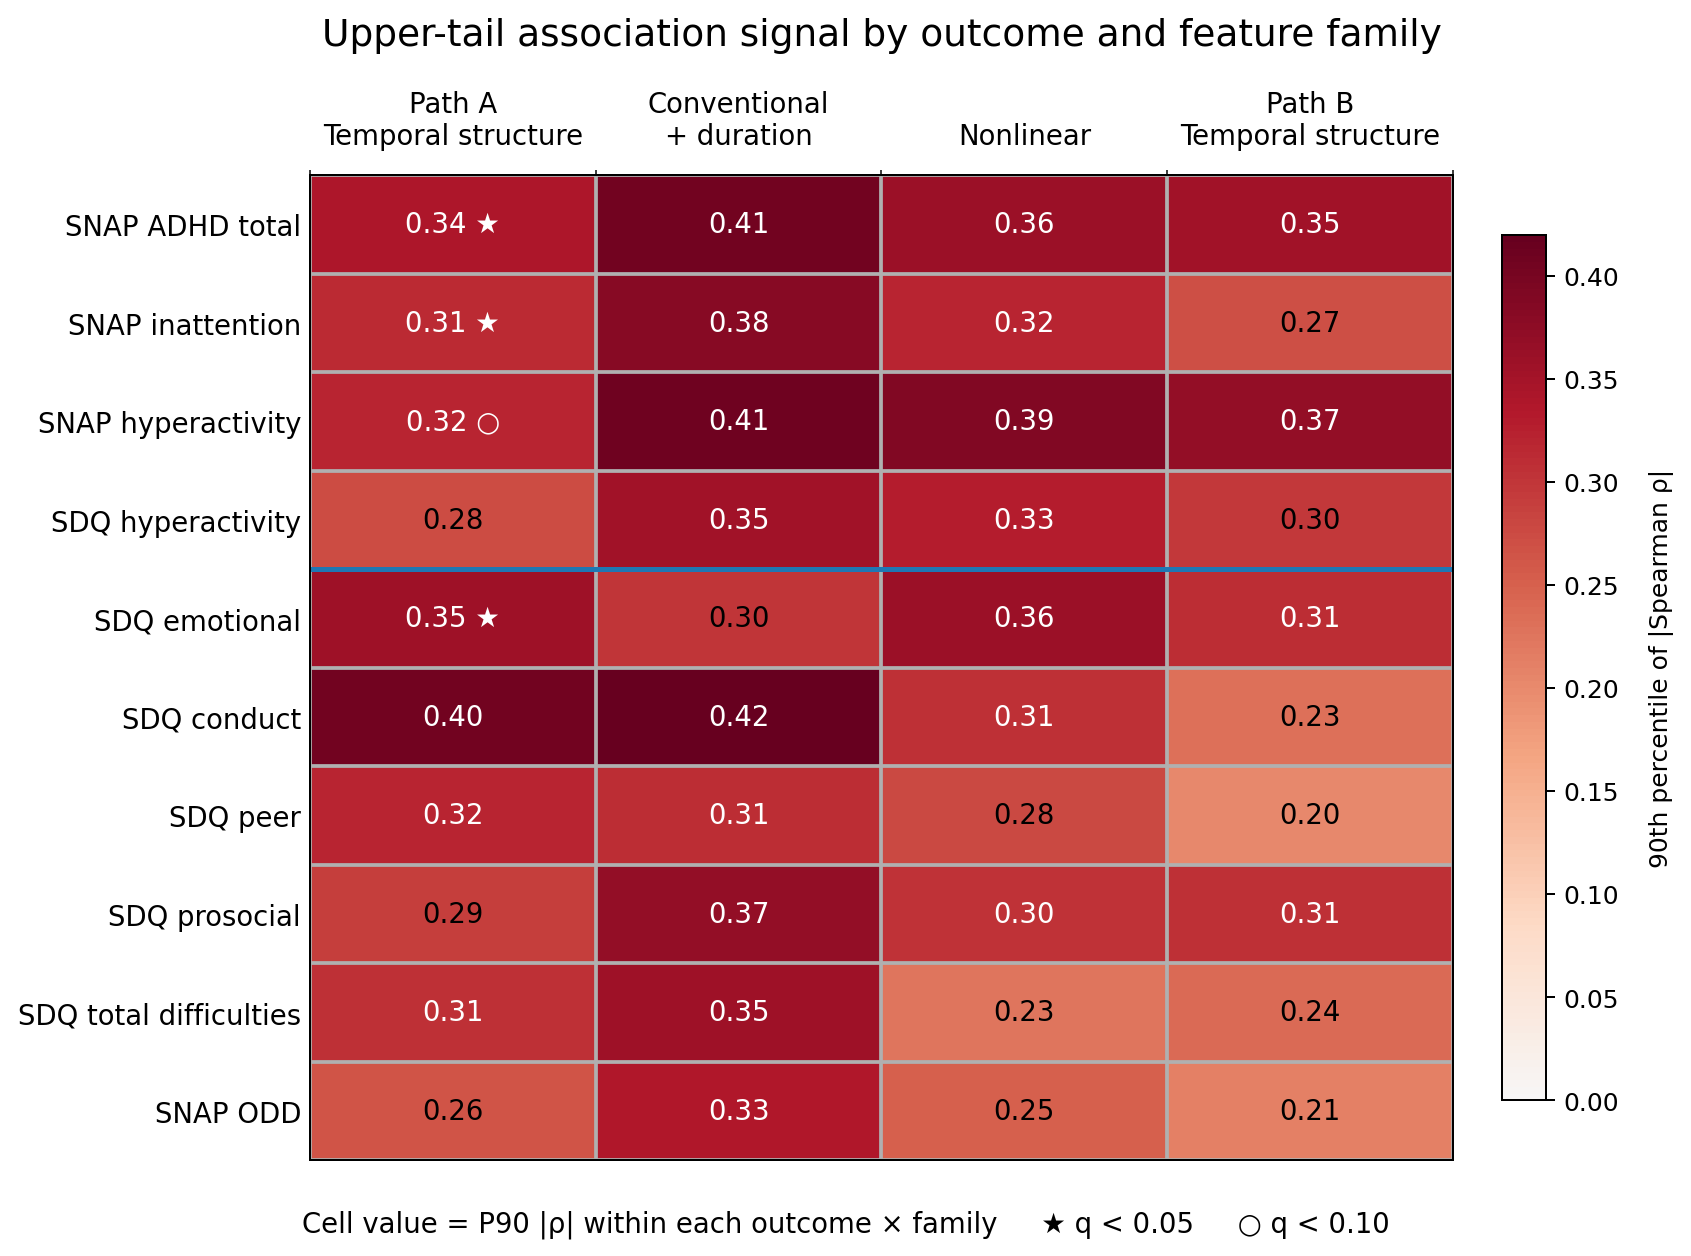

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# -----------------------------
# 1. 行列顺序
# -----------------------------
target_order = [
    "snap_adhd_total",
    "snap_inatt",
    "snap_hyper",
    "sdq_hyper",
    "sdq_emo",
    "sdq_cond",
    "sdq_peer",
    "sdq_pro",
    "sdq_totdiff",
    "snap_odd"
]

target_labels = {
    "snap_adhd_total": "SNAP ADHD total",
    "snap_inatt": "SNAP inattention",
    "snap_hyper": "SNAP hyperactivity",
    "sdq_hyper": "SDQ hyperactivity",
    "sdq_emo": "SDQ emotional",
    "sdq_cond": "SDQ conduct",
    "sdq_peer": "SDQ peer",
    "sdq_pro": "SDQ prosocial",
    "sdq_totdiff": "SDQ total difficulties",
    "snap_odd": "SNAP ODD"
}

family_order = [
    "Path A",
    "Conventional + duration",
    "Nonlinear",
    "Path B"
]

family_labels = {
    "Path A": "Path A\nTemporal structure",
    "Conventional + duration": "Conventional\n+ duration",
    "Nonlinear": "Nonlinear",
    "Path B": "Path B\nTemporal structure"
}

# -----------------------------
# 2. 构造热力图矩阵
# fine_summary 是你前面已经生成的 40 行汇总表
# -----------------------------
heatmap_data = (
    fine_summary
    .pivot(
        index="target",
        columns="fine_family",
        values="p90_abs_rho"
    )
    .reindex(
        index=target_order,
        columns=family_order
    )
)

# 每个 target × family 中最小的 q
q_data = (
    fine_summary
    .pivot(
        index="target",
        columns="fine_family",
        values="min_q_fdr"
    )
    .reindex(
        index=target_order,
        columns=family_order
    )
)

# -----------------------------
# 3. 使用 RdBu_r 的白→红部分
# -----------------------------
base_cmap = plt.get_cmap("RdBu_r")

white_to_red = LinearSegmentedColormap.from_list(
    "white_to_red",
    base_cmap(np.linspace(0.5, 1.0, 256))
)

# -----------------------------
# 4. 绘图
# -----------------------------
fig, ax = plt.subplots(
    figsize=(9.5, 7),
    dpi=180
)

vmin = 0
vmax = np.nanmax(heatmap_data.values)

image = ax.imshow(
    heatmap_data.values,
    cmap=white_to_red,
    vmin=vmin,
    vmax=vmax,
    aspect="auto"
)

# 坐标标签
ax.set_xticks(np.arange(len(family_order)))
ax.set_xticklabels(
    [family_labels[x] for x in family_order],
    fontsize=11
)

ax.set_yticks(np.arange(len(target_order)))
ax.set_yticklabels(
    [target_labels[x] for x in target_order],
    fontsize=11
)

ax.xaxis.tick_top()
ax.tick_params(axis="x", length=0, pad=10)
ax.tick_params(axis="y", length=0)

# 单元格边界
ax.set_xticks(
    np.arange(-0.5, len(family_order), 1),
    minor=True
)
ax.set_yticks(
    np.arange(-0.5, len(target_order), 1),
    minor=True
)

ax.grid(
    which="minor",
    linewidth=1.5
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False
)

# -----------------------------
# 5. 单元格数值与 FDR 符号
# ★ q < 0.05
# ○ 0.05 <= q < 0.10
# -----------------------------
for i in range(len(target_order)):
    for j in range(len(family_order)):

        value = heatmap_data.iloc[i, j]
        q_value = q_data.iloc[i, j]

        if pd.isna(value):
            continue

        if q_value < 0.05:
            marker = " ★"
        elif q_value < 0.10:
            marker = " ○"
        else:
            marker = ""

        text_color = (
            "white"
            if value > 0.72 * vmax
            else "black"
        )

        ax.text(
            j,
            i,
            f"{value:.2f}{marker}",
            ha="center",
            va="center",
            fontsize=11,
            color=text_color
        )

# 分隔 primary ADHD 与 secondary outcomes
ax.axhline(
    3.5,
    linewidth=2
)

# -----------------------------
# 6. 标题与色条
# -----------------------------
ax.set_title(
    "Upper-tail association signal by outcome and feature family",
    fontsize=15,
    pad=52
)

colorbar = fig.colorbar(
    image,
    ax=ax,
    fraction=0.035,
    pad=0.04
)

colorbar.set_label(
    "90th percentile of |Spearman ρ|",
    rotation=90,
    labelpad=12
)

fig.text(
    0.5,
    0.015,
    "Cell value = P90 |ρ| within each outcome × family     "
    "★ q < 0.05     ○ q < 0.10",
    ha="center",
    fontsize=11
)

plt.tight_layout(
    rect=[0, 0.05, 1, 1]
)

plt.savefig(
    "A_track_target_by_feature_family_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "A_track_target_by_feature_family_heatmap.svg",
    bbox_inches="tight"
)

plt.show()

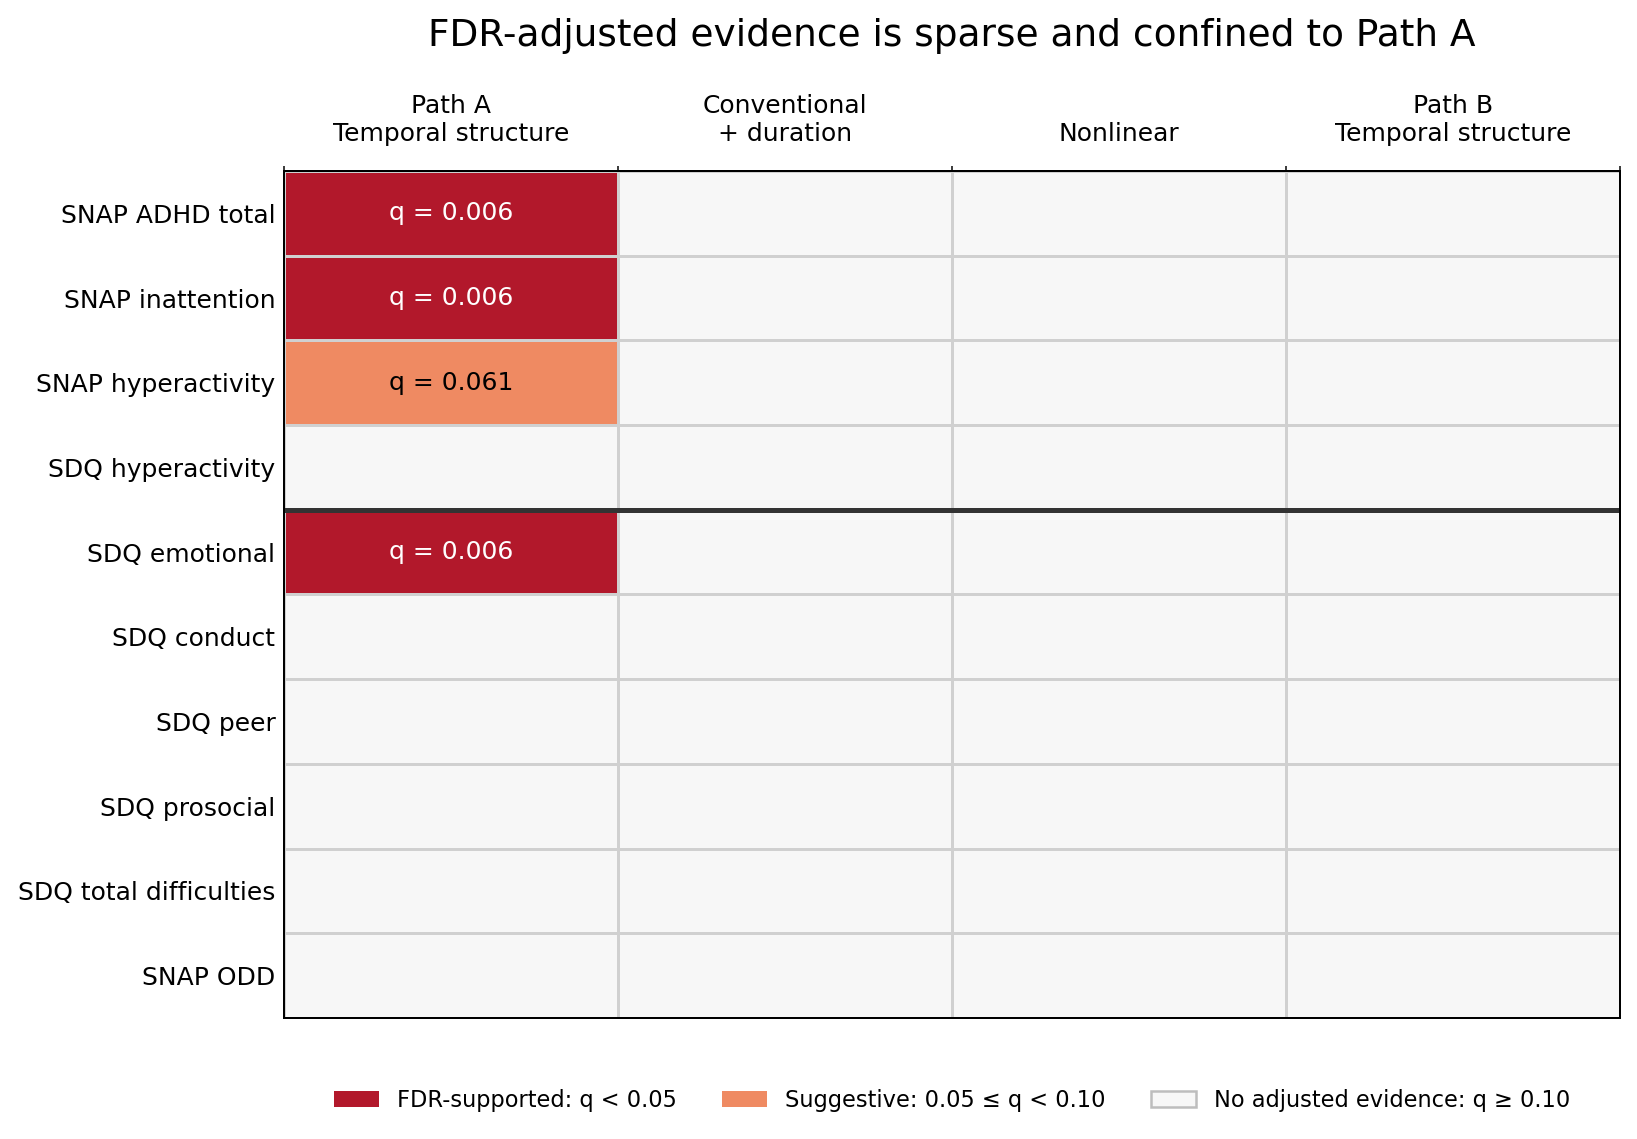

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

# --------------------------------------------------
# 1. 行列顺序
# --------------------------------------------------
target_order = [
    "snap_adhd_total",
    "snap_inatt",
    "snap_hyper",
    "sdq_hyper",
    "sdq_emo",
    "sdq_cond",
    "sdq_peer",
    "sdq_pro",
    "sdq_totdiff",
    "snap_odd"
]

target_labels = {
    "snap_adhd_total": "SNAP ADHD total",
    "snap_inatt": "SNAP inattention",
    "snap_hyper": "SNAP hyperactivity",
    "sdq_hyper": "SDQ hyperactivity",
    "sdq_emo": "SDQ emotional",
    "sdq_cond": "SDQ conduct",
    "sdq_peer": "SDQ peer",
    "sdq_pro": "SDQ prosocial",
    "sdq_totdiff": "SDQ total difficulties",
    "snap_odd": "SNAP ODD"
}

family_order = [
    "Path A",
    "Conventional + duration",
    "Nonlinear",
    "Path B"
]

family_labels = {
    "Path A": "Path A\nTemporal structure",
    "Conventional + duration": "Conventional\n+ duration",
    "Nonlinear": "Nonlinear",
    "Path B": "Path B\nTemporal structure"
}

# --------------------------------------------------
# 2. 每个 target × family 的最小 FDR q
# fine_summary 是前面生成的 40 行汇总表
# --------------------------------------------------
q_matrix = (
    fine_summary
    .pivot(
        index="target",
        columns="fine_family",
        values="min_q_fdr"
    )
    .reindex(
        index=target_order,
        columns=family_order
    )
)

# --------------------------------------------------
# 3. 把 q 转换成三档证据等级
#
# 0 = q >= 0.10
# 1 = 0.05 <= q < 0.10
# 2 = q < 0.05
# --------------------------------------------------
evidence_matrix = np.zeros_like(
    q_matrix.values,
    dtype=float
)

evidence_matrix[
    (q_matrix.values < 0.10)
    & (q_matrix.values >= 0.05)
] = 1

evidence_matrix[
    q_matrix.values < 0.05
] = 2

# --------------------------------------------------
# 4. 分类配色
# --------------------------------------------------
cmap = ListedColormap([
    "#f7f7f7",  # no adjusted evidence
    "#ef8a62",  # suggestive
    "#b2182b"   # FDR-supported
])

norm = BoundaryNorm(
    boundaries=[-0.5, 0.5, 1.5, 2.5],
    ncolors=cmap.N
)

# --------------------------------------------------
# 5. 绘图
# --------------------------------------------------
fig, ax = plt.subplots(
    figsize=(9.2, 6.8),
    dpi=180
)

ax.imshow(
    evidence_matrix,
    cmap=cmap,
    norm=norm,
    aspect="auto"
)

# 坐标
ax.set_xticks(np.arange(len(family_order)))
ax.set_xticklabels(
    [family_labels[x] for x in family_order],
    fontsize=10
)

ax.set_yticks(np.arange(len(target_order)))
ax.set_yticklabels(
    [target_labels[x] for x in target_order],
    fontsize=10
)

ax.xaxis.tick_top()
ax.tick_params(axis="x", length=0, pad=10)
ax.tick_params(axis="y", length=0)

# 单元格边界
ax.set_xticks(
    np.arange(-0.5, len(family_order), 1),
    minor=True
)
ax.set_yticks(
    np.arange(-0.5, len(target_order), 1),
    minor=True
)

ax.grid(
    which="minor",
    color="#d0d0d0",
    linewidth=1.2
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False
)

# --------------------------------------------------
# 6. 只在 q < 0.10 的格子写数值
# --------------------------------------------------
for i in range(len(target_order)):
    for j in range(len(family_order)):

        q_value = q_matrix.iloc[i, j]

        if pd.isna(q_value) or q_value >= 0.10:
            continue

        text_color = (
            "white"
            if q_value < 0.05
            else "black"
        )

        ax.text(
            j,
            i,
            f"q = {q_value:.3f}",
            ha="center",
            va="center",
            fontsize=10,
            fontweight="medium",
            color=text_color
        )

# Primary ADHD outcomes 与 secondary outcomes 分隔线
ax.axhline(
    3.5,
    color="#333333",
    linewidth=2
)

# --------------------------------------------------
# 7. 标题与图例
# --------------------------------------------------
ax.set_title(
    "FDR-adjusted evidence is sparse and confined to Path A",
    fontsize=15,
    pad=50
)

legend_handles = [
    Patch(
        facecolor="#b2182b",
        edgecolor="none",
        label="FDR-supported: q < 0.05"
    ),
    Patch(
        facecolor="#ef8a62",
        edgecolor="none",
        label="Suggestive: 0.05 ≤ q < 0.10"
    ),
    Patch(
        facecolor="#f7f7f7",
        edgecolor="#bdbdbd",
        label="No adjusted evidence: q ≥ 0.10"
    )
]

ax.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.06),
    ncol=3,
    frameon=False,
    fontsize=9
)

plt.tight_layout(
    rect=[0, 0.05, 1, 1]
)

plt.savefig(
    "A_track_FDR_evidence_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "A_track_FDR_evidence_heatmap.svg",
    bbox_inches="tight"
)

plt.show()

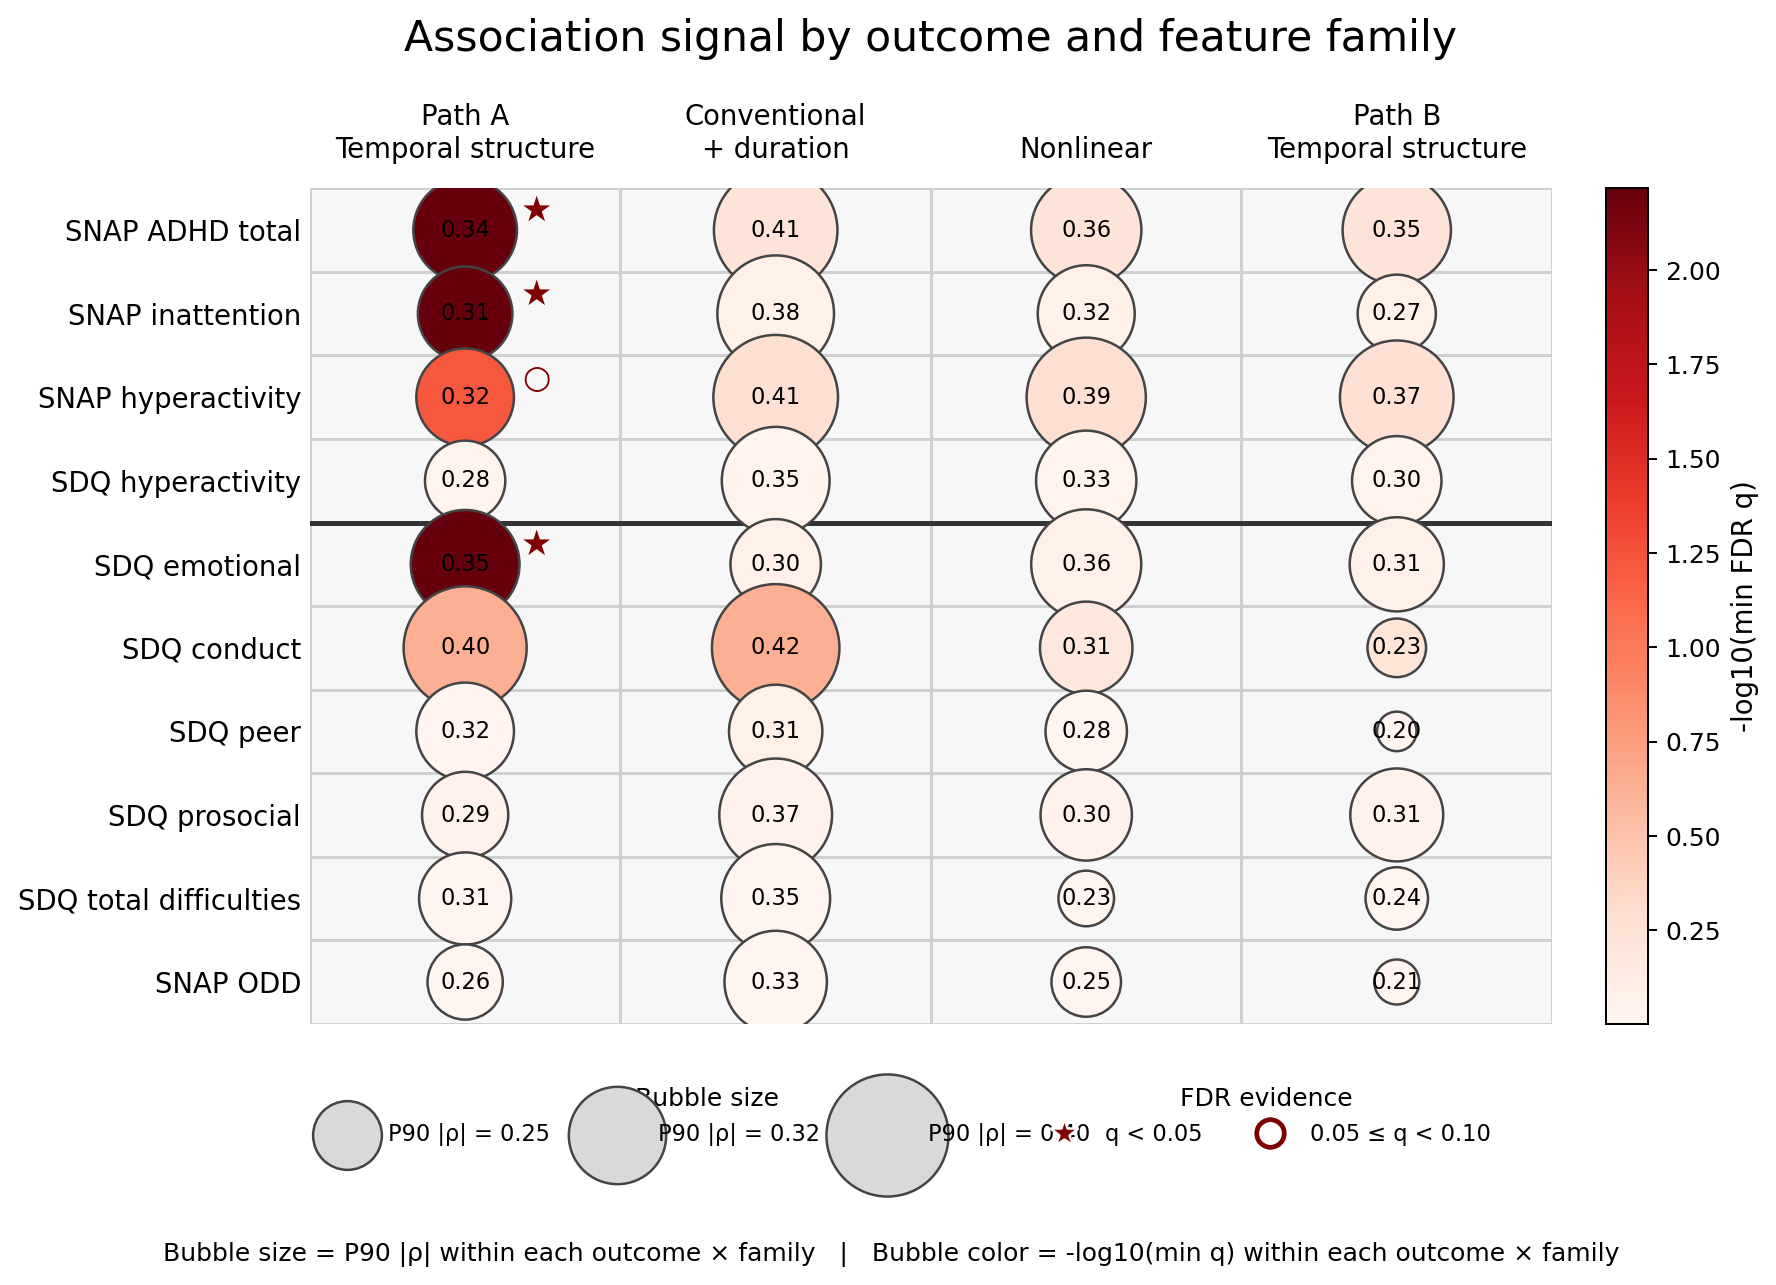

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 1. 行列顺序
# =========================================================
target_order = [
    "snap_adhd_total",
    "snap_inatt",
    "snap_hyper",
    "sdq_hyper",
    "sdq_emo",
    "sdq_cond",
    "sdq_peer",
    "sdq_pro",
    "sdq_totdiff",
    "snap_odd"
]

target_labels = {
    "snap_adhd_total": "SNAP ADHD total",
    "snap_inatt": "SNAP inattention",
    "snap_hyper": "SNAP hyperactivity",
    "sdq_hyper": "SDQ hyperactivity",
    "sdq_emo": "SDQ emotional",
    "sdq_cond": "SDQ conduct",
    "sdq_peer": "SDQ peer",
    "sdq_pro": "SDQ prosocial",
    "sdq_totdiff": "SDQ total difficulties",
    "snap_odd": "SNAP ODD"
}

family_order = [
    "Path A",
    "Conventional + duration",
    "Nonlinear",
    "Path B"
]

family_labels = {
    "Path A": "Path A\nTemporal structure",
    "Conventional + duration": "Conventional\n+ duration",
    "Nonlinear": "Nonlinear",
    "Path B": "Path B\nTemporal structure"
}

# =========================================================
# 2. 从 fine_summary 提取需要的数据
# 需要 fine_summary 至少包含：
# target, fine_family, p90_abs_rho, min_q_fdr
# =========================================================
plot_df = fine_summary[
    ["target", "fine_family", "p90_abs_rho", "min_q_fdr"]
].copy()

plot_df["target"] = pd.Categorical(
    plot_df["target"],
    categories=target_order,
    ordered=True
)

plot_df["fine_family"] = pd.Categorical(
    plot_df["fine_family"],
    categories=family_order,
    ordered=True
)

plot_df = plot_df.sort_values(["target", "fine_family"]).reset_index(drop=True)

# 数值映射
plot_df["x"] = plot_df["fine_family"].cat.codes
plot_df["y"] = plot_df["target"].cat.codes

# =========================================================
# 3. 气泡大小：p90_abs_rho
#    这里做一个线性缩放，可以自己微调
# =========================================================
size_min = 250
size_max = 2600

p90_min = plot_df["p90_abs_rho"].min()
p90_max = plot_df["p90_abs_rho"].max()

plot_df["bubble_size"] = (
    size_min
    + (plot_df["p90_abs_rho"] - p90_min)
    / (p90_max - p90_min)
    * (size_max - size_min)
)

# =========================================================
# 4. 颜色：-log10(min_q_fdr)
#    q 越小，值越大，颜色越深
# =========================================================
# 避免 log10(0)
plot_df["q_for_color"] = plot_df["min_q_fdr"].clip(lower=1e-6)
plot_df["neglog10_q"] = -np.log10(plot_df["q_for_color"])

# =========================================================
# 5. 画图
# =========================================================
fig, ax = plt.subplots(figsize=(10, 7.2), dpi=180)

# 背景网格
for x in range(len(family_order)):
    for y in range(len(target_order)):
        rect = plt.Rectangle(
            (x - 0.5, y - 0.5),
            1, 1,
            facecolor="#f7f7f7",
            edgecolor="#d0d0d0",
            linewidth=1.2,
            zorder=0
        )
        ax.add_patch(rect)

# 气泡
sc = ax.scatter(
    plot_df["x"],
    plot_df["y"],
    s=plot_df["bubble_size"],
    c=plot_df["neglog10_q"],
    cmap="Reds",
    edgecolors="#444444",
    linewidths=1.0,
    zorder=3
)

# 在气泡里写 p90 值
for _, row in plot_df.iterrows():
    ax.text(
        row["x"],
        row["y"],
        f'{row["p90_abs_rho"]:.2f}',
        ha="center",
        va="center",
        fontsize=9,
        color="black",
        zorder=4
    )

# q < 0.05 加星号
sig_df = plot_df[plot_df["min_q_fdr"] < 0.05]
for _, row in sig_df.iterrows():
    ax.text(
        row["x"] + 0.23,
        row["y"] - 0.23,
        "★",
        fontsize=14,
        color="#7f0000",
        ha="center",
        va="center",
        zorder=5
    )

# 0.05 <= q < 0.10 加空心圈标记
sugg_df = plot_df[
    (plot_df["min_q_fdr"] >= 0.05) &
    (plot_df["min_q_fdr"] < 0.10)
]
for _, row in sugg_df.iterrows():
    ax.text(
        row["x"] + 0.23,
        row["y"] - 0.23,
        "○",
        fontsize=13,
        color="#7f0000",
        ha="center",
        va="center",
        zorder=5
    )

# =========================================================
# 6. 坐标轴设置
# =========================================================
ax.set_xlim(-0.5, len(family_order) - 0.5)
ax.set_ylim(len(target_order) - 0.5, -0.5)

ax.set_xticks(range(len(family_order)))
ax.set_xticklabels(
    [family_labels[f] for f in family_order],
    fontsize=11
)

ax.set_yticks(range(len(target_order)))
ax.set_yticklabels(
    [target_labels[t] for t in target_order],
    fontsize=11
)

ax.xaxis.tick_top()
ax.tick_params(axis="x", length=0, pad=10)
ax.tick_params(axis="y", length=0)

# primary vs secondary 分隔线
ax.axhline(
    3.5,
    color="#333333",
    linewidth=2
)

# 去掉边框
for spine in ax.spines.values():
    spine.set_visible(False)

# =========================================================
# 7. 标题、色条、图例
# =========================================================
ax.set_title(
    "Association signal by outcome and feature family",
    fontsize=17,
    pad=55
)

cbar = plt.colorbar(sc, ax=ax, fraction=0.035, pad=0.04)
cbar.set_label("-log10(min FDR q)", fontsize=11)

# 自定义 bubble-size 图例
legend_sizes = [0.25, 0.32, 0.40]
legend_scaled_sizes = [
    size_min + (v - p90_min) / (p90_max - p90_min) * (size_max - size_min)
    for v in legend_sizes
]

size_handles = [
    plt.scatter([], [], s=s, color="#d9d9d9", edgecolors="#444444")
    for s in legend_scaled_sizes
]

size_legend = ax.legend(
    size_handles,
    [f"P90 |ρ| = {v:.2f}" for v in legend_sizes],
    title="Bubble size",
    scatterpoints=1,
    frameon=False,
    loc="lower center",
    bbox_to_anchor=(0.32, -0.17),
    ncol=3,
    fontsize=9,
    title_fontsize=10
)
ax.add_artist(size_legend)

marker_handles = [
    plt.Line2D([0], [0], marker="*", color="w",
               markerfacecolor="#7f0000", markersize=12, linestyle="None",
               label="q < 0.05"),
    plt.Line2D([0], [0], marker="$○$", color="#7f0000",
               markersize=12, linestyle="None",
               label="0.05 ≤ q < 0.10")
]

ax.legend(
    handles=marker_handles,
    title="FDR evidence",
    frameon=False,
    loc="lower center",
    bbox_to_anchor=(0.77, -0.17),
    ncol=2,
    fontsize=9,
    title_fontsize=10
)

# 底部说明
fig.text(
    0.5,
    0.02,
    "Bubble size = P90 |ρ| within each outcome × family   |   "
    "Bubble color = -log10(min q) within each outcome × family",
    ha="center",
    fontsize=10
)

plt.tight_layout(rect=[0, 0.06, 1, 1])

plt.savefig(
    "A_track_bubble_matrix_target_by_family.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "A_track_bubble_matrix_target_by_family.svg",
    bbox_inches="tight"
)

plt.show()

In [26]:
import numpy as np
import pandas as pd

family_reg = reg.copy()

# Path B：有 partial-rho 的那 45 个 feature
is_path_b = family_reg["rho_partial_uamag"].notna()

# Path A：带有明确 window + percentile 参数的特征
is_path_a = family_reg["feature"].str.contains(
    r"_w(?:0\.5|1|2|5|10)_p(?:10|20|30|40|50|60|70|80|90)$",
    regex=True,
    na=False
) & ~is_path_b

family_reg["broad_family"] = np.select(
    [is_path_b, is_path_a],
    ["Path B", "Path A"],
    default="Other"
)

print(
    family_reg[
        ["feature", "broad_family"]
    ]
    .drop_duplicates()
    ["broad_family"]
    .value_counts()
)

broad_family
Other     293
Path A    270
Path B     45
Name: count, dtype: int64


In [27]:
family_reg = reg.copy()

# Path B：45 个有 partial rho 的 features
is_path_b = family_reg["rho_partial_uamag"].notna()

# Path A：270 个带 window + percentile 的特征
is_path_a_grid = family_reg["feature"].str.contains(
    r"_w(?:0\.5|1|2|5|10)_p(?:10|20|30|40|50|60|70|80|90)$",
    regex=True,
    na=False
)

# Path A：另外 5 个 within_win_sd
is_path_a_within = family_reg["feature"].str.contains(
    r"^within_win_sd_w(?:0\.5|1|2|5|10)$",
    regex=True,
    na=False
)

is_path_a = (
    is_path_a_grid
    | is_path_a_within
) & ~is_path_b

family_reg["broad_family"] = np.select(
    [is_path_b, is_path_a],
    ["Path B", "Path A"],
    default="Other"
)

print(
    family_reg[
        ["feature", "broad_family"]
    ]
    .drop_duplicates()
    ["broad_family"]
    .value_counts()
)

broad_family
Other     288
Path A    275
Path B     45
Name: count, dtype: int64


In [28]:
family_summary = (
    family_reg
    .assign(
        abs_rho=family_reg["rho"].abs()
    )
    .groupby(
        ["target", "broad_family"],
        observed=True
    )
    .agg(
        n_features=("feature", "nunique"),

        # 关联强度
        median_abs_rho=("abs_rho", "median"),
        p90_abs_rho=("abs_rho", lambda x: x.quantile(0.90)),
        max_abs_rho=("abs_rho", "max"),

        # 强关联数量与比例
        n_abs_rho_ge_05=(
            "abs_rho",
            lambda x: (x >= 0.5).sum()
        ),
        prop_abs_rho_ge_05=(
            "abs_rho",
            lambda x: (x >= 0.5).mean()
        ),

        # FDR
        min_q_fdr=("q_fdr", "min"),
        n_q_fdr_lt_05=(
            "q_fdr",
            lambda x: (x < 0.05).sum()
        ),

        # LOOCV
        max_loo_r2cv=("loo_r2cv", "max"),
        median_loo_r2cv=("loo_r2cv", "median"),
        n_loo_r2cv_gt_0=(
            "loo_r2cv",
            lambda x: (x > 0).sum()
        ),
        prop_loo_r2cv_gt_0=(
            "loo_r2cv",
            lambda x: (x > 0).mean()
        )
    )
    .reset_index()
)

print(
    family_summary
    .round(3)
    .to_string(index=False)
)

         target broad_family  n_features  median_abs_rho  p90_abs_rho  max_abs_rho  n_abs_rho_ge_05  prop_abs_rho_ge_05  min_q_fdr  n_q_fdr_lt_05  max_loo_r2cv  median_loo_r2cv  n_loo_r2cv_gt_0  prop_loo_r2cv_gt_0
       sdq_cond        Other         288           0.160        0.390        0.624               13               0.045      0.231              0         0.419           -0.061               70               0.243
       sdq_cond       Path A         275           0.162        0.403        0.668               13               0.047      0.231              0         0.279           -0.064               72               0.262
       sdq_cond       Path B          45           0.077        0.231        0.391                0               0.000      0.599              0         0.048           -0.065                2               0.044
        sdq_emo        Other         288           0.165        0.309        0.495                0               0.000      0.880              

In [40]:
import numpy as np
import pandas as pd

# =========================================================
# 1. 取出 A轨二分类结果
#    不依赖 type 的具体字符串，直接用 auc 是否存在来识别
# =========================================================

bin_uni = reg.loc[
    reg["auc"].notna()
].copy()

print("Binary rows:", len(bin_uni))
print("Binary targets:", bin_uni["target"].nunique())
print("Features per target:")
print(bin_uni.groupby("target")["feature"].nunique())

# 正常情况下应当大约是：
# 10 targets
# 每个 target 608 features
# 总共 6080 rows

Binary rows: 0
Binary targets: 0
Features per target:
Series([], Name: feature, dtype: int64)


In [42]:
import pandas as pd

# 按你的实际路径调整
uni = pd.read_csv("/Users/shiyu/Projects/adhd-segmentation/analysis/A_univariate.csv")

print("shape:", uni.shape)
print("\ncolumns:")
print(uni.columns.tolist())

print("\nnon-null counts:")
print(
    uni[
        ["rho", "auc", "rho_partial_uamag", "auc_partial_uamag"]
    ].notna().sum()
)

print("\ntype counts:")
print(uni["type"].value_counts(dropna=False))

shape: (12160, 12)

columns:
['target', 'type', 'feature', 'rho', 'auc', 'perm_p', 'loo_r2cv', 'loo_rmse', 'loo_mae', 'rho_partial_uamag', 'auc_partial_uamag', 'q_fdr']

non-null counts:
rho                  6080
auc                  6080
rho_partial_uamag     450
auc_partial_uamag     450
dtype: int64

type counts:
type
cont    6080
bin     6080
Name: count, dtype: int64


In [43]:
import numpy as np
import pandas as pd

bin_uni = uni.loc[
    uni["type"] == "bin"
].copy()

# 方向无关的区分能力
# 例如 AUC=0.20 和 AUC=0.80 都表示同样强的区分，只是方向相反
bin_uni["auc_star"] = np.maximum(
    bin_uni["auc"],
    1 - bin_uni["auc"]
)

binary_summary = (
    bin_uni
    .groupby("target")
    .agg(
        n_features=("feature", "nunique"),

        median_auc_star=("auc_star", "median"),
        p90_auc_star=("auc_star", lambda x: x.quantile(0.90)),
        max_auc_star=("auc_star", "max"),

        n_auc_star_ge_070=(
            "auc_star",
            lambda x: (x >= 0.70).sum()
        ),
        n_auc_star_ge_075=(
            "auc_star",
            lambda x: (x >= 0.75).sum()
        ),
        n_auc_star_ge_080=(
            "auc_star",
            lambda x: (x >= 0.80).sum()
        ),

        n_perm_p_lt_05=(
            "perm_p",
            lambda x: (x < 0.05).sum()
        ),

        min_perm_p=("perm_p", "min"),

        min_q_fdr=("q_fdr", "min"),

        n_q_fdr_lt_05=(
            "q_fdr",
            lambda x: (x < 0.05).sum()
        )
    )
    .reset_index()
    .sort_values(
        ["min_q_fdr", "max_auc_star"],
        ascending=[True, False]
    )
)

print(
    binary_summary
    .round(3)
    .to_string(index=False)
)

               target  n_features  median_auc_star  p90_auc_star  max_auc_star  n_auc_star_ge_070  n_auc_star_ge_075  n_auc_star_ge_080  n_perm_p_lt_05  min_perm_p  min_q_fdr  n_q_fdr_lt_05
       sdq_cond__qbin         608            0.604         0.781         0.914                161                 91                 43              91       0.000      0.127              0
    sdq_totdiff__qbin         608            0.581         0.704         0.896                 62                 27                  9              33       0.001      0.210              0
snap_adhd_total__qbin         608            0.590         0.695         0.896                 60                 15                  4              20       0.000      0.231              0
      sdq_hyper__qbin         608            0.586         0.729         0.850                 92                 37                  9              49       0.002      0.504              0
       sdq_peer__qbin         608            0.574

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. 数据
# ============================================================

uni = pd.read_csv("analysis/A_univariate.csv")
labels = pd.read_csv("analysis/target_labels.csv")

bin_uni = uni.loc[uni["type"] == "bin"].copy()

# 方向无关的区分能力
# AUC=.2 和 AUC=.8 都记成 AUC*=.8
bin_uni["auc_star"] = np.maximum(
    bin_uni["auc"],
    1 - bin_uni["auc"]
)

targets = sorted(bin_uni["target"].unique())

print("Targets:", len(targets))
print("Rows:", len(bin_uni))

FileNotFoundError: [Errno 2] No such file or directory: 'analysis/A_univariate.csv'